# Edge AI Model Optimization: Pruning and Quantization for Human Activity Recognition

## Notebook Overview

How can we make an activity-recognition model smaller and efficient enough for edge deployment while preserving useful prediction accuracy?

In this notebook, we train a neural network on smartphone sensor features, then optimize it using **quantization** and **pruning**. We compare the original and optimized models using classification accuracy, macro F1, stored model size, sparsity, and measured inference latency.

We will cover:

1. **Dataset and task:** understand the smartphone measurements, the six activity classes, and why evaluation must separate participants.
2. **Baseline model:** train an FP32 multilayer perceptron and establish reference accuracy, parameter count, file size, and latency.
3. **Quantization:** compare FP16, INT8, and lower-bit weight representations and investigate the trade-off between precision, storage, and accuracy.
4. **Pruning:** remove low-magnitude weights, compare global and layer-wise pruning, and use fine-tuning with fixed masks to recover accuracy.
5. **Combining the techniques:** combine pruning and quantization and select a compact candidate using validation results.
6. **ONNX deployment:** export models and evaluate their execution with ONNX Runtime.
7. **Final evaluation:** compare the frozen models on the official test set and explain the accuracy, storage, and runtime trade-offs.

## Task Details: What Are We Predicting?

### Dataset

We use the **Human Activity Recognition Using Smartphones (UCI HAR)** dataset.

**Dataset page and download:** [UCI Human Activity Recognition Using Smartphones](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones).

The dataset records 30 volunteers carrying a waist-mounted smartphone. Its accelerometer and gyroscope capture motion at 50 Hz. Measurements are grouped into 2.56-second windows with 50% overlap. Each window has **561 precomputed time- and frequency-domain features** and one activity label.

The official split contains **7,352 training windows from 21 participants** and **2,947 test windows from 9 different participants**. In this notebook, we further split the training participants into training and validation groups; the official test set is reserved for final evaluation.

### Input and prediction target

This is a **supervised multiclass classification** task. Given the 561-feature vector for one sensor window, the model predicts **one of six activities**:

| Dataset label | Label used in the notebook | Activity |
|---|---|---|
| 1 | 0 | Walking |
| 2 | 1 | Walking upstairs |
| 3 | 2 | Walking downstairs |
| 4 | 3 | Sitting |
| 5 | 4 | Standing |
| 6 | 5 | Lying down (`LAYING`) |

For example, features extracted from a window recorded while someone climbs stairs should lead to the prediction **Walking upstairs**. The network produces six class scores, and we select the activity with the highest score. Participant IDs are used to keep the evaluation groups separate, not as model inputs.

The classifier uses the supplied feature vectors. Raw sensor traces are explored for illustration; they are not the direct input to this MLP.

### Aim of the notebook

Our aim is to **reduce the storage requirements of the activity classifier while retaining accuracy and measuring the effect on inference time**. We start with a **561 → 128 → 64 → 6** FP32 neural network, then study how far its weights can be pruned and their numerical precision reduced.

By the end, you should be able to:

- Explain how quantization changes weight precision and how pruning introduces zero weights.
- Measure accuracy and macro F1 alongside file size, sparsity, and latency.
- Compare pruned models before and after fine-tuning.
- Choose an optimized model using validation results, then assess generalization to unseen participants on the test set.
- Export a model to ONNX and check whether deployment preserves its predictions.
- Explain why a smaller stored model does not automatically run faster: runtime support, sparse storage, and decoding costs matter. The low-bit PyTorch experiments reconstruct weights for floating-point execution, so their bit width alone does not establish low-bit inference speed.

**Practical outcome:** a measured comparison of the baseline, quantized, pruned, and combined models, together with deployment files. On a real device, extracting the 561 features also consumes resources; this notebook focuses on optimizing the classifier.


---

## 1. SETUP

#### 1.1 INSTALLATION AND IMPORTS

In [1]:
import sys; print("Using installed dependencies for validation")

Using installed dependencies for validation


In [2]:
# ============================================================
# IMPORTS
# ============================================================

# Python standard library
import copy
import contextlib
import csv
import io
import json
import logging
import platform
import time
import warnings
import zlib
from pathlib import Path


# Numerical computing and visualization
import numpy as np
import matplotlib.pyplot as plt


# PyTorch
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.utils.prune as torch_prune


# Scikit-learn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


# Jupyter
from IPython.display import Markdown, display


# ONNX and ONNX Runtime
import onnx
import onnxruntime as ort
import onnxscript

from onnx import helper, numpy_helper, TensorProto

from onnxruntime.quantization import (
    quantize_dynamic,
    QuantType,
)

from onnxruntime.quantization.shape_inference import quant_pre_process
from onnxruntime.quantization.matmul_nbits_quantizer import MatMulNBitsQuantizer


# Reduce unnecessary ONNX Runtime logging
logging.getLogger(
    "onnxruntime.quantization"
).setLevel(logging.ERROR)


# ============================================================
# ENVIRONMENT INFORMATION
# ============================================================

print("\nEnvironment ready.")
print(f"Python          : {sys.version.split()[0]}")
print(f"PyTorch         : {torch.__version__}")
print(f"ONNX            : {onnx.__version__}")
print(f"ONNX Runtime    : {ort.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"ORT providers   : {ort.get_available_providers()}")


Environment ready.
Python          : 3.13.9
PyTorch         : 2.11.0+cpu
ONNX            : 1.22.0
ONNX Runtime    : 1.23.2
CUDA available  : False
ORT providers   : ['AzureExecutionProvider', 'CPUExecutionProvider']


#### 1.2 HELPER FUNCTIONS

**quantize_weights()**

 - Converts the model to a selected precision, supporting FP16, INT8, INT4, INT3, INT2, and INT1. INT8 uses PyTorch's native dynamic quantization, while lower-bit formats are simulated by quantizing and dequantizing the weights for standard PyTorch layers.

**prune_unstructured()**

 - Removes individual weights with the smallest magnitudes across the model. The specified sparsity determines what percentage of weights are set to zero.

**prune_structured()**

 - Removes complete groups of weights, such as neurons, instead of individual weights. Structured pruning is more hardware-friendly because entire structures can potentially be removed from the network.

**get_sparsity()**

 - Measures how many model weights are zero after pruning. For example, a sparsity of 0.80 means that 80% of the considered weights are zero.

**finetune_model()**

 - Continues training a pruned model for a small number of epochs. Fine-tuning can recover some of the accuracy lost during pruning.

**evaluate_model()**

 - Evaluates a PyTorch model on a dataset and calculates common classification metrics such as accuracy, macro F1 score, and loss. It provides a consistent way to compare the original and optimized models.

**export_onnx()**

 - Exports a PyTorch model to the ONNX format. ONNX allows the trained model to be used by different inference runtimes and deployment environments.

**create_onnx_session()**

 - Loads an exported ONNX model into ONNX Runtime for inference. The returned session can then be used to run predictions without PyTorch.

1.2.1 QUANTIZATION HELPERS

In [3]:
def quantize_weights(model, bits):
    """
    Quantize model weights to a selected precision.

    Supported:
        16 -> FP16
         8 -> INT8 dynamic quantization
         4 -> INT4 affine weight quantization
         3 -> INT3 affine weight quantization
         2 -> INT2 affine weight quantization
         1 -> 1-bit binary weight quantization
    """

    model = copy.deepcopy(model).eval()

    # FP16
    if bits == 16:
        return model.half()

    # INT8 - native PyTorch dynamic quantization
    if bits == 8:
        return torch.ao.quantization.quantize_dynamic(
            model,
            {nn.Linear},
            dtype=torch.qint8
        )

    if bits not in (1, 2, 3, 4):
        raise ValueError("bits must be one of: 1, 2, 3, 4, 8, 16")

    with torch.no_grad():

        for module in model.modules():

            if not isinstance(module, nn.Linear):
                continue

            weight = module.weight.data

            # ----------------------------------------
            # 1-bit binary quantization
            # ----------------------------------------
            if bits == 1:

                scale = weight.abs().mean(dim=1, keepdim=True)

                reconstructed = torch.where(
                    weight >= 0,
                    scale,
                    -scale
                )

            # ----------------------------------------
            # INT2 / INT3 / INT4 affine quantization
            # ----------------------------------------
            else:

                qmax = 2 ** bits - 1

                # Separate range for each output neuron
                lower = weight.amin(
                    dim=1,
                    keepdim=True
                ).clamp(max=0)

                upper = weight.amax(
                    dim=1,
                    keepdim=True
                ).clamp(min=0)

                scale = (upper - lower) / qmax

                # Avoid division by zero
                scale = torch.where(
                    scale == 0,
                    torch.ones_like(scale),
                    scale
                )

                zero_point = torch.round(
                    -lower / scale
                ).clamp(0, qmax)

                codes = torch.round(
                    weight / scale
                ) + zero_point

                codes = codes.clamp(
                    0,
                    qmax
                )

                reconstructed = (
                    codes - zero_point
                ) * scale

            module.weight.data.copy_(reconstructed)

    return model

1.2.2 PRUNING HELPERS

Unstructured Pruning

In [4]:
# ============================================================
# PRUNING HELPERS
# ============================================================

def prune_unstructured(model, sparsity):
    """
    Global unstructured magnitude pruning.

    Removes the smallest-magnitude weights across all Linear layers.

    sparsity:
        0.2 = remove 20% of weights
        0.8 = remove 80% of weights
    """
    model = copy.deepcopy(model)

    parameters = [
        (module, "weight")
        for module in model.modules()
        if isinstance(module, nn.Linear)
    ]

    torch_prune.global_unstructured(
        parameters,
        pruning_method=torch_prune.L1Unstructured,
        amount=sparsity
    )

    # Make pruning permanent
    for module, _ in parameters:
        torch_prune.remove(module, "weight")

    return model

Structured Pruning

In [5]:
def prune_structured(model, sparsity, dim=0):
    """
    Structured pruning of Linear layers.

    Removes complete rows/neurons based on their L2 norm.

    sparsity:
        Fraction of structures to prune.

    dim=0:
        Prune output neurons.
    """
    model = copy.deepcopy(model)

    for module in model.modules():

        if isinstance(module, nn.Linear):

            torch_prune.ln_structured(
                module,
                name="weight",
                amount=sparsity,
                n=2,
                dim=dim
            )

            torch_prune.remove(module, "weight")

    return model

Measure sparsity

In [6]:
def get_sparsity(model):
    """Return the fraction of zero weights in Linear layers."""

    total = 0
    zeros = 0

    for module in model.modules():

        if isinstance(module, nn.Linear):
            weight = module.weight.data

            total += weight.numel()
            zeros += (weight == 0).sum().item()

    return zeros / total

Fine-tuning

In [7]:
def finetune_pruned_model(
    model,
    train_loader,
    X_val,
    y_val,
    masks,
    epochs=10,
    lr=1e-4
):
    model = copy.deepcopy(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Epoch 0: model before fine-tuning
    best_metrics = evaluate_model(model, X_val, y_val)
    best_loss = best_metrics["loss"]
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        model.train()

        for features, labels in train_loader:
            optimizer.zero_grad()

            logits = model(features)
            loss = nn.functional.cross_entropy(logits, labels)

            loss.backward()
            optimizer.step()

            # Keep pruned weights at zero
            with torch.no_grad():
                for name, mask in masks.items():
                    model.get_submodule(name).weight.mul_(mask)

        # Validation after each epoch
        metrics = evaluate_model(
            model,
            X_val,
            y_val
        )

        if metrics["loss"] < best_loss:
            best_loss = metrics["loss"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    return model.eval(), best_epoch

1.2.3 ONNX HELPERS

ONNX export

In [8]:
# ============================================================
# ONNX HELPERS
# ============================================================

def export_onnx(model, path, example_input):
    """Export a PyTorch model to ONNX."""

    model.eval()

    torch.onnx.export(
        model,
        (example_input,),
        str(path),
        input_names=["features"],
        output_names=["logits"],
        dynamic_shapes=(
            {0: torch.export.Dim("batch")},
        ),
        dynamo=True,
        external_data=False
    )

    return Path(path)

ONNX Runtime

In [9]:
def create_onnx_session(path, decode_at_load=False, save_optimized_graph=None):
    """Load an ONNX model on CPU with one thread and optional graph inspection."""
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    options.log_severity_level = 3
    if decode_at_load:
        options.add_session_config_entry("session.disable_quant_qdq", "1")
    if save_optimized_graph is not None:
        options.optimized_model_filepath = str(save_optimized_graph)
    return ort.InferenceSession(
        str(path), options, providers=["CPUExecutionProvider"]
    )

1.2.4 TRAINING HELPERS

Evaluate Model

In [10]:
def evaluate_model(
    model,
    X,
    y,
    input_dtype=torch.float32,
    batch_size=64
):
    """Evaluate a PyTorch model using accuracy, macro F1, and cross-entropy loss."""

    model.eval()

    total_loss = 0.0
    predictions = []

    with torch.inference_mode():
        for start in range(0, len(y), batch_size):
            inputs = X[start:start + batch_size].to(input_dtype)
            labels = y[start:start + batch_size]

            logits = model(inputs).float()

            total_loss += nn.functional.cross_entropy(
                logits,
                labels,
                reduction="sum"
            ).item()

            predictions.append(logits.argmax(dim=1))

    predictions = torch.cat(predictions)

    return {
        "accuracy": accuracy_score(
            y.numpy(),
            predictions.numpy()
        ),
        "macro_f1": f1_score(
            y.numpy(),
            predictions.numpy(),
            average="macro"
        ),
        "loss": total_loss / len(y)
    }

---

## 2. Load the UCI HAR Dataset

**Goal:** predict a person's activity from smartphone motion sensors.

- **Participants:** 30 volunteers, aged 19-48, wearing a smartphone at the waist.

- **Sensors:** accelerometer and gyroscope, sampled at **50 Hz** (50 readings per second).

- **One sample:** a **2.56-second window** containing 128 readings per signal. Consecutive windows overlap by 50%.

- **Inputs used here:** **561 precomputed features** per window, such as means, standard deviations, and frequency-based measurements. The dataset documentation states that these features are normalized to [-1, 1].

- **Targets:** six activities: walking, walking upstairs, walking downstairs, sitting, standing, and lying down (named `LAYING` in the dataset).

- **Official split:** **7,352 training samples** and **2,947 test samples**. Participants are separated between training (21 people) and test (9 people).


We start with the feature vectors in `X_train.txt` and `X_test.txt`. The `Inertial Signals` folders also contain sensor windows that we can explore later for models that work directly with signals. On a device, a model using these 561 features would also need the corresponding feature extraction pipeline.

**Source:** the local `UCI HAR Dataset/README.txt` and `features_info.txt` supplied with the dataset (Anguita et al., 2013).

### Load features and labels
Run this notebook from the folder containing `UCI HAR Dataset`. Only NumPy is needed for this step. We convert activity labels from **1-6 to 0-5** for later neural-network training.


In [11]:
DATA_DIR = Path("UCI HAR Dataset")

# Each row contains 561 features for one sensor window.
X_train = np.loadtxt(DATA_DIR / "train" / "X_train.txt", dtype=np.float32)
X_test = np.loadtxt(DATA_DIR / "test" / "X_test.txt", dtype=np.float32)

# Use zero-based class labels: 0, 1, ..., 5.
y_train = np.loadtxt(DATA_DIR / "train" / "y_train.txt", dtype=np.int64) - 1
y_test = np.loadtxt(DATA_DIR / "test" / "y_test.txt", dtype=np.int64) - 1

# Read the activity names in the same order as the class labels.
activity_labels = np.loadtxt(DATA_DIR / "activity_labels.txt", dtype=str)
class_names = activity_labels[:, 1].tolist()

# Keep participant IDs as metadata, not as model inputs.
subject_train = np.loadtxt(DATA_DIR / "train" / "subject_train.txt", dtype=np.int64)
subject_test = np.loadtxt(DATA_DIR / "test" / "subject_test.txt", dtype=np.int64)


In [12]:
print(f"Training: X = {X_train.shape}, y = {y_train.shape}")
print(f"Test:     X = {X_test.shape}, y = {y_test.shape}")
print(f"Features per sample: {X_train.shape[1]}")
print(f"Participants: {len(np.unique(subject_train))} train, "
      f"{len(np.unique(subject_test))} test")

print("\nSamples per activity:")
print(f"{'Label':<7}{'Activity':<23}{'Train':>7}{'Test':>7}")
for label, name in enumerate(class_names):
    print(f"{label:<7}{name:<23}{np.sum(y_train == label):>7}"
          f"{np.sum(y_test == label):>7}")

print("\nFirst training sample (first 8 features):", X_train[0, :8])
print("Its activity:", class_names[y_train[0]])


Training: X = (7352, 561), y = (7352,)
Test:     X = (2947, 561), y = (2947,)
Features per sample: 561
Participants: 21 train, 9 test

Samples per activity:
Label  Activity                 Train   Test
0      WALKING                   1226    496
1      WALKING_UPSTAIRS          1073    471
2      WALKING_DOWNSTAIRS         986    420
3      SITTING                   1286    491
4      STANDING                  1374    532
5      LAYING                    1407    537

First training sample (first 8 features): [ 0.2885845  -0.02029417 -0.13290514 -0.9952786  -0.9831106  -0.9135265
 -0.99511206 -0.9831846 ]
Its activity: STANDING


### How to read these arrays

- `X_train` and `X_test`: model inputs, with shape **(number of samples, 561 features)**.
- `y_train` and `y_test`: the correct activity label for each sample.
- `class_names`: converts a numeric label into an activity name, for example `class_names[0]` is `WALKING`.
- `subject_train` and `subject_test`: identify the participant who produced each sample.

Keep the official test set for final evaluation. When we add a validation set for model tuning, split the training data **by participant** so the same person does not appear in both training and validation.


---

## 3. Explore Data (Before Training)

**Opening question:** Can a phone tell whether you are walking, sitting, or lying down just from its motion sensors?

We will explore **training data only**. Each row is a sensor window, not a separate person; overlapping windows from the same participant are related observations.

This section uses NumPy, Matplotlib, and scikit-learn. If needed, run `%pip install numpy matplotlib scikit-learn` in a notebook cell once, then restart the kernel and run from the top.

All plots below use files from the local `UCI HAR Dataset/train` folder; feature definitions come from `features.txt` and `features_info.txt`.

In [13]:
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
BLUE = "#3572B0"
activity_names = [name.replace("_", " ").title() for name in class_names]
activity_names[-1] = "Lying down"

print("Missing/non-finite feature values:", np.sum(~np.isfinite(X_train)))
print("Training participants:", len(np.unique(subject_train)))
print("Participant overlap with test:",
      len(np.intersect1d(subject_train, subject_test)))


Missing/non-finite feature values: 0
Training participants: 21
Participant overlap with test: 0


### 3.1 Do we have similar amounts of each activity?

Count **windows**, not people. Before looking at the chart, guess which activity has the most examples.

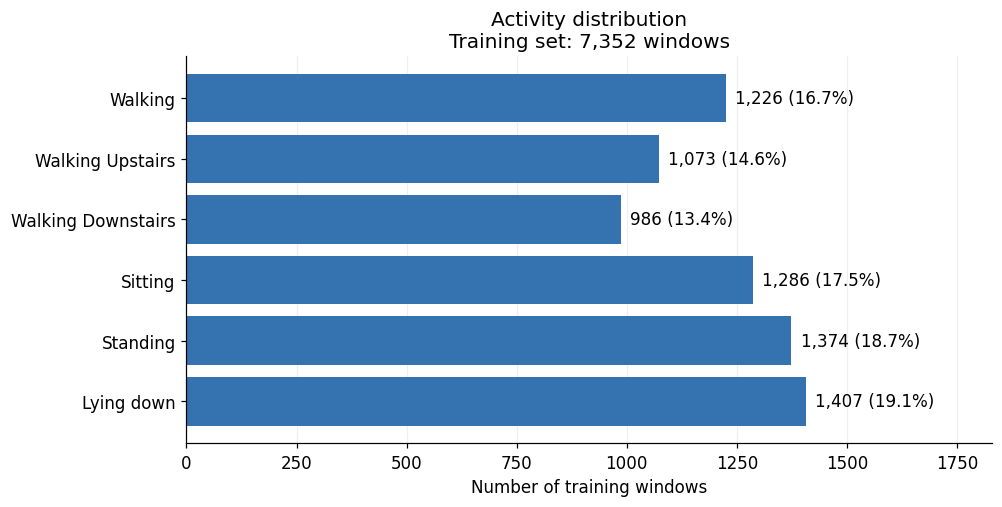

Most / least frequent class: 1.43 times
Always predicting the largest class gives 19.1% accuracy on this training set.


In [14]:
counts = np.bincount(y_train, minlength=len(class_names))
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
bars = ax.barh(activity_names, counts, color=BLUE)
ax.bar_label(bars, labels=[f"{n:,} ({n / len(y_train):.1%})" for n in counts],
             padding=6)
ax.invert_yaxis()
ax.set_xlim(0, counts.max() * 1.3)
ax.set_xlabel("Number of training windows")
ax.set_title(f"Activity distribution\nTraining set: {len(y_train):,} windows")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
plt.show()

print(f"Most / least frequent class: {counts.max() / counts.min():.2f} times")
print(f"Always predicting the largest class gives {counts.max() / counts.sum():.1%} "
      "accuracy on this training set.")

**What to notice:** All six activities have substantial representation, but their counts are not identical. The largest class is about 1.43 times the smallest. We should later inspect performance for each activity as well as overall accuracy.

**Ask students:** Could a classifier achieve nonzero accuracy without learning anything about motion?

### 3.2 What does an activity look like to the sensor?

Here we read the **body acceleration along the phone's X axis**, measured in units of gravity (`g`). These are supplied, preprocessed signals with the gravity component removed.

To keep the comparison simple, we select one participant who has all six activities and show the **first available window per activity**. These are illustrative examples, not average or representative signals for the whole dataset. Each panel is a separate 2.56-second window.

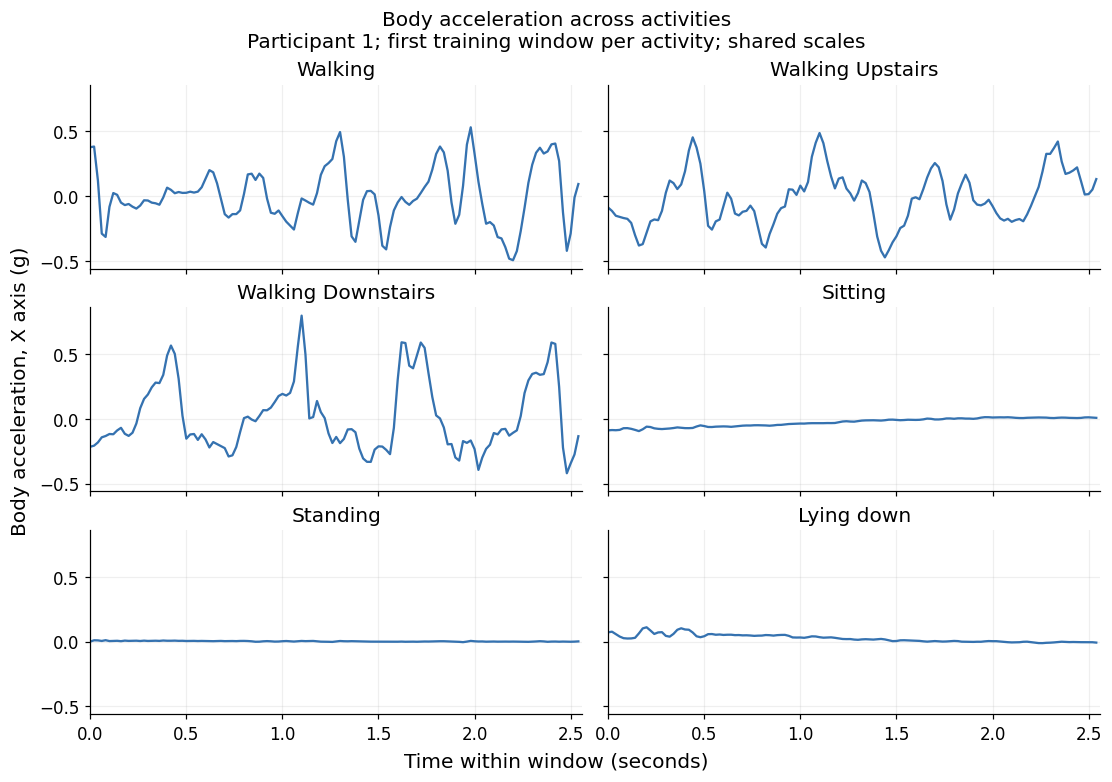

In [15]:
body_acc_x = np.loadtxt(
    DATA_DIR / "train" / "Inertial Signals" / "body_acc_x_train.txt",
    dtype=np.float32,
)
participant = next(int(s) for s in np.unique(subject_train)
                   if len(np.unique(y_train[subject_train == s])) == len(class_names))
time_seconds = np.arange(body_acc_x.shape[1]) / 50  # 50 Hz sampling

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True,
                         layout="constrained")
for label, ax in enumerate(axes.flat):
    row = np.flatnonzero((subject_train == participant) & (y_train == label))[0]
    ax.plot(time_seconds, body_acc_x[row], color=BLUE, linewidth=1.5)
    ax.set_title(activity_names[label])
    ax.set_xlim(0, 2.56)
    ax.grid(alpha=0.2)
fig.suptitle(f"Body acceleration across activities\nParticipant {participant}; "
             "first training window per activity; shared scales")
fig.supxlabel("Time within window (seconds)")
fig.supylabel("Body acceleration, X axis (g)")
plt.show()


**What to notice:** Compare the size and rhythm of the fluctuations. These examples show more movement during walking activities than during stationary postures. Body acceleration alone may give little information about the difference between sitting and standing.

**Ask students:** What single number could summarize how much a signal fluctuates? Try the **standard deviation**. Would the phone's orientation or another sensor axis help distinguish postures?

### 3.3 Can one feature separate the activities?

The feature `tBodyAcc-std()-X` summarizes the variation in X-axis body acceleration within each window. We now compare **all training windows**, not just six examples.

The feature values were normalized by the dataset authors. A negative value here does **not** mean a negative standard deviation; it is a value on the transformed scale.

In each boxplot, the line is the median, the box contains the middle 50% of values, and whiskers extend to the most extreme observations within 1.5 box widths of the box. Dots show observations beyond the whiskers, not necessarily errors.

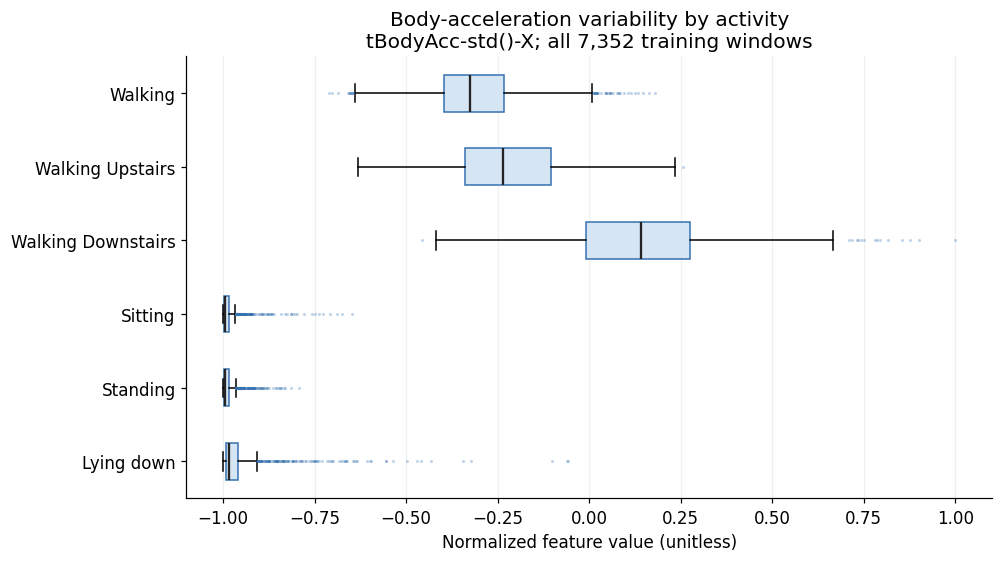

In [16]:
feature_names = np.loadtxt(DATA_DIR / "features.txt", dtype=str)[:, 1]
feature_index = np.flatnonzero(feature_names == "tBodyAcc-std()-X")[0]
values_by_activity = [X_train[y_train == label, feature_index]
                      for label in range(len(class_names))]

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
ax.boxplot(values_by_activity, vert=False, patch_artist=True,
           boxprops={"facecolor": "#D6E5F3", "edgecolor": BLUE},
           medianprops={"color": "#242424", "linewidth": 1.5},
           flierprops={"marker": ".", "markersize": 2,
                       "markeredgecolor": BLUE, "alpha": 0.3})
ax.set_yticks(np.arange(1, 7), activity_names)
ax.invert_yaxis()
ax.set_xlabel("Normalized feature value (unitless)")
ax.set_title("Body-acceleration variability by activity\n"
             "tBodyAcc-std()-X; all 7,352 training windows")
ax.grid(axis="x", alpha=0.2)
plt.show()

**What to notice:** This feature helps distinguish movement from stationary postures, but the activity distributions overlap. A simple threshold cannot perfectly identify all six activities.

**Ask students:** If we add a second feature describing orientation, which activities might become easier to distinguish?

### 3.4 What do 561 features look like in two dimensions?

**Principal Component Analysis (PCA)** finds directions of large variation in the inputs. We standardize each feature using training-set statistics, then project the windows onto two directions. Labels are used only to highlight activities, not to fit PCA.

Every panel shows the **same projection and axis limits**: grey dots are all training windows and blue dots highlight one activity. This view helps us inspect structure without hiding classes behind each other.

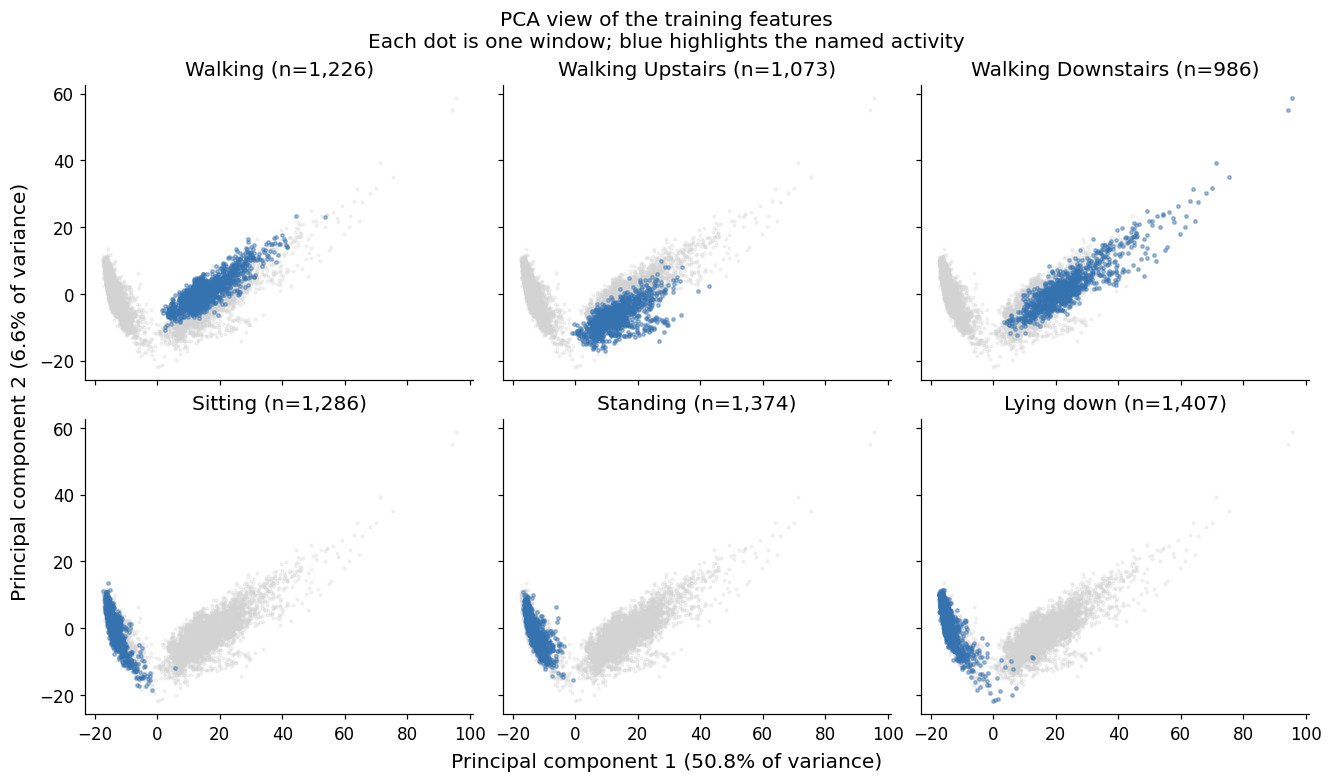

The two components retain 57.4% of standardized feature variance.


In [17]:
# New arrays for exploration: preserve X_train and X_test for later modeling.
X_scaled_eda = StandardScaler().fit_transform(X_train)
pca_eda = PCA(n_components=2, svd_solver="randomized", random_state=42)
X_pca = pca_eda.fit_transform(X_scaled_eda)
explained = pca_eda.explained_variance_ratio_ * 100

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True,
                         layout="constrained")
for label, ax in enumerate(axes.flat):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], s=3, color="#D3D3D3", alpha=0.25)
    mask = y_train == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=5, color=BLUE, alpha=0.4)
    ax.set_title(f"{activity_names[label]} (n={mask.sum():,})")
fig.suptitle("PCA view of the training features\n"
             "Each dot is one window; blue highlights the named activity")
fig.supxlabel(f"Principal component 1 ({explained[0]:.1f}% of variance)")
fig.supylabel(f"Principal component 2 ({explained[1]:.1f}% of variance)")
plt.show()
print(f"The two components retain {explained.sum():.1f}% of standardized feature variance.")


**Interpret carefully:** PCA preserves variation, not necessarily the information most useful for classification. Overlap in two dimensions does not prove that a model using all 561 features will fail. Separate-looking groups also do not establish performance on unseen people.

**Ask students:** Is the percentage of variance retained the same as classification accuracy? **No**: no classifier has been trained here.

### From exploration to our Edge AI experiment

We have seen how sensor windows become features, why multiple features can help, and why activity-specific evaluation matters. Next we can hold out training participants for validation and train a baseline network.

For edge deployment, we will measure accuracy, model size, and latency. Feature extraction also uses device resources, so optimizing the neural network addresses only one part of the full sensor-to-prediction pipeline.

---

## 4. Train a baseline neural network

**Goal:** learn a reference model before quantization or pruning.

We train locally on the CPU using PyTorch. No pretrained model is needed. The input is the original **561 features**, and the output is six activity scores. The PCA coordinates above are not used for training.

If PyTorch is missing, run `%pip install torch` once in a notebook cell, restart the kernel, and run from the top. This section writes the best weights and experiment settings to `baseline_artifacts`.


### 4.1 Settings and reproducibility

We fix random seeds and use one CPU thread for a consistent local comparison. Results and timings can still differ across computers and library versions.

In [18]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.001
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
device = torch.device("cpu")

print(f"Device: {device} | PyTorch: {torch.__version__}")

Device: cpu | PyTorch: 2.11.0+cpu


### 4.2 Hold out participants for validation

We reserve about 20% of the **21 training participants**, rounded up to five, for validation. The split is by person, not by window, so a participant cannot appear on both sides. The percentage of windows may differ from 20%.

The official nine test participants remain reserved for the final evaluation. We use the supplied normalized features directly, without an additional scaler. If we later add a scaler or feature selection, it must be fitted on the new training subset only.

In [19]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(splitter.split(X_train, y_train, groups=subject_train))
train_subjects = np.unique(subject_train[train_idx])
val_subjects = np.unique(subject_train[val_idx])

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(subject_test)
assert set(val_subjects).isdisjoint(subject_test)
assert set(y_train[train_idx]) == set(y_train[val_idx]) == set(range(6))

print("Training participants:", train_subjects.tolist())
print("Validation participants:", val_subjects.tolist())
print(f"Windows: {len(train_idx):,} train | {len(val_idx):,} validation")
print(f"{'Activity':<23}{'Train':>8}{'Valid':>8}")
for label, name in enumerate(activity_names):
    print(f"{name:<23}{np.sum(y_train[train_idx] == label):>8}"
          f"{np.sum(y_train[val_idx] == label):>8}")

train_dataset = TensorDataset(torch.from_numpy(X_train[train_idx]),
                              torch.from_numpy(y_train[train_idx]))
val_dataset = TensorDataset(torch.from_numpy(X_train[val_idx]),
                            torch.from_numpy(y_train[val_idx]))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


Training participants: [5, 6, 7, 8, 11, 14, 16, 17, 19, 21, 22, 23, 26, 28, 29, 30]
Validation participants: [1, 3, 15, 25, 27]
Windows: 5,551 train | 1,801 validation
Activity                  Train   Valid
Walking                     888     338
Walking Upstairs            797     276
Walking Downstairs          744     242
Sitting                     993     293
Standing                   1053     321
Lying down                 1076     331


### 4.3 Build the model

Our multilayer perceptron (MLP) is **561 → 128 → 64 → 6**. Each hidden layer combines features and applies ReLU, which replaces negative values with zero.

The final layer returns **logits** (unscaled class scores). Do not add Softmax before `CrossEntropyLoss`: this loss already handles the required transformation. We use the largest score to choose an activity.

In [20]:
def make_baseline():
    return nn.Sequential(
        nn.Linear(561, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 6),
    )

torch.manual_seed(SEED)
baseline_model = make_baseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)
parameter_count = sum(p.numel() for p in baseline_model.parameters())
print(baseline_model)
print(f"Trainable parameters: {parameter_count:,}")


Sequential(
  (0): Linear(in_features=561, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=6, bias=True)
)
Trainable parameters: 80,582


### 4.4 Train and select the best epoch

For each batch, we predict activities, compute the loss, calculate gradients, and update the weights. Validation uses no gradient updates.

An **epoch** is one pass through the training subset. We save the weights with the lowest validation loss, rather than automatically choosing the final epoch. Training metrics below are collected while weights change within an epoch; validation metrics use the fixed weights at its end.

In [21]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.inference_mode():
        for features, labels in loader:
            logits = model(features.to(device))
            labels = labels.to(device)
            total_loss += criterion(logits, labels).item() * len(labels)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total

history = {key: [] for key in ("train_loss", "val_loss", "train_acc", "val_acc")}
best_val_loss = float("inf")
training_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    baseline_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = baseline_model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += len(labels)

    val_loss, val_acc = evaluate(baseline_model, val_loader)
    history["train_loss"].append(total_loss / total)
    history["train_acc"].append(correct / total)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_weights = copy.deepcopy(baseline_model.state_dict())
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | train loss {total_loss / total:.4f} | "
              f"val loss {val_loss:.4f} | val accuracy {val_acc:.1%}")

training_seconds = time.perf_counter() - training_start
baseline_model.load_state_dict(best_weights)
baseline_model.eval()
print(f"Restored epoch {best_epoch} (lowest validation loss: {best_val_loss:.4f}).")
print(f"Training time: {training_seconds:.1f} seconds")


Epoch  1 | train loss 0.7885 | val loss 0.4208 | val accuracy 81.1%


Epoch  5 | train loss 0.1009 | val loss 0.1434 | val accuracy 95.4%


Epoch 10 | train loss 0.0677 | val loss 0.1375 | val accuracy 95.3%


Epoch 15 | train loss 0.0589 | val loss 0.1695 | val accuracy 95.2%


Epoch 20 | train loss 0.0624 | val loss 0.1577 | val accuracy 95.4%


Epoch 25 | train loss 0.0529 | val loss 0.1212 | val accuracy 96.1%


Epoch 30 | train loss 0.0420 | val loss 0.1678 | val accuracy 95.8%
Restored epoch 26 (lowest validation loss: 0.1000).
Training time: 9.8 seconds


### 4.5 Inspect learning curves

Look for falling training loss and improving validation performance. If training improves while validation loss rises, the model may be overfitting. The dotted line identifies the checkpoint selected by validation loss.

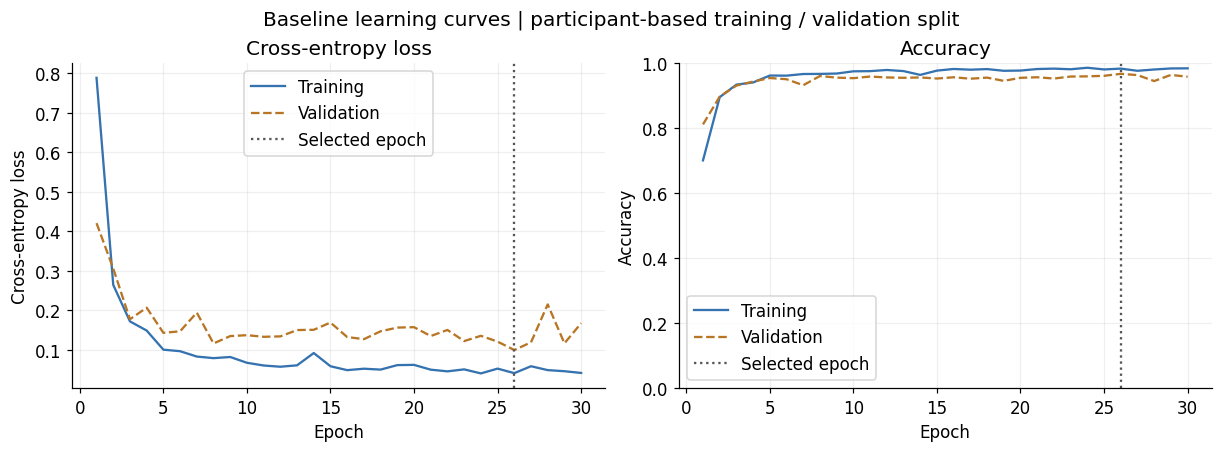

In [22]:
epochs = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metric, title in zip(axes, ("loss", "acc"), ("Cross-entropy loss", "Accuracy")):
    ax.plot(epochs, history[f"train_{metric}"], color=BLUE, label="Training")
    ax.plot(epochs, history[f"val_{metric}"], color="#B87524",
            linestyle="--", label="Validation")
    ax.axvline(best_epoch, color="#555555", linestyle=":", label="Selected epoch")
    ax.set(xlabel="Epoch", ylabel=title, title=title)
    ax.grid(alpha=0.2)
    ax.legend()
axes[1].set_ylim(0, 1)
fig.suptitle("Baseline learning curves | participant-based training / validation split")
plt.show()


### 4.6 Which activities are confused?

Evaluate the restored checkpoint on validation participants. **Accuracy** counts all correct predictions. **Macro F1** averages the F1 score of each activity equally. The confusion matrix uses rows for true activities and columns for predictions; a perfect classifier would have counts only on the diagonal.

These are development results: the validation set also selected the epoch, so it is not an independent final test.

Majority-class baseline validation accuracy: 18.4%
MLP validation accuracy: 96.67%
MLP validation macro F1: 0.9631
                    precision    recall  f1-score   support

           Walking      0.997     0.988     0.993       338
  Walking Upstairs      0.873     0.996     0.931       276
Walking Downstairs      0.995     0.839     0.910       242
           Sitting      0.960     0.986     0.973       293
          Standing      0.981     0.966     0.973       321
        Lying down      1.000     0.997     0.998       331

          accuracy                          0.967      1801
         macro avg      0.968     0.962     0.963      1801
      weighted avg      0.969     0.967     0.967      1801



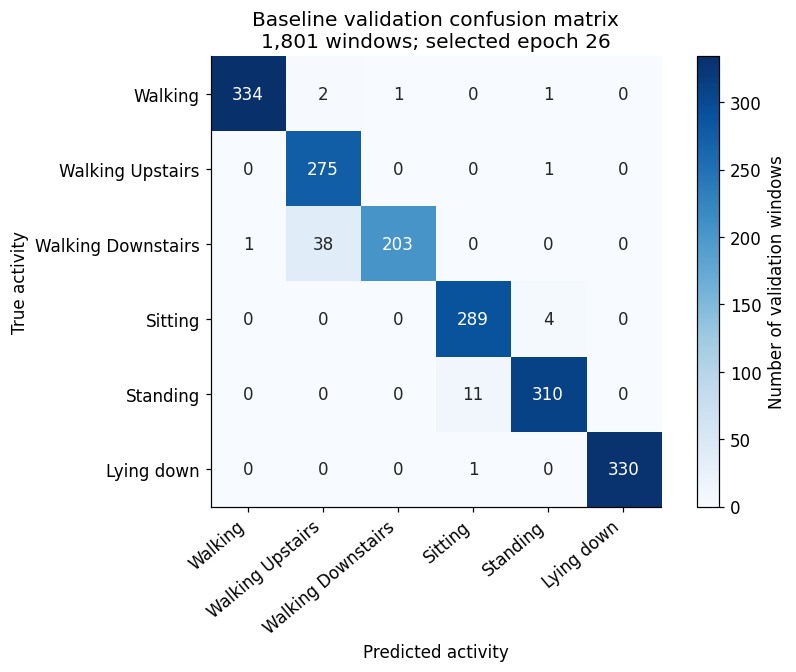

In [23]:
with torch.inference_mode():
    val_predictions = baseline_model(val_dataset.tensors[0].to(device)).argmax(1).cpu().numpy()
val_labels = y_train[val_idx]
val_accuracy = accuracy_score(val_labels, val_predictions)
val_macro_f1 = f1_score(val_labels, val_predictions, average="macro")
majority_class = np.bincount(y_train[train_idx], minlength=6).argmax()
print(f"Majority-class baseline validation accuracy: {(val_labels == majority_class).mean():.1%}")
print(f"MLP validation accuracy: {val_accuracy:.2%}")
print(f"MLP validation macro F1: {val_macro_f1:.4f}")
print(classification_report(val_labels, val_predictions, labels=np.arange(6),
                             target_names=activity_names, digits=3, zero_division=0))

cm = confusion_matrix(val_labels, val_predictions, labels=np.arange(6))
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
im = ax.imshow(cm, cmap="Blues", vmin=0)
fig.colorbar(im, ax=ax, label="Number of validation windows")
ax.set_xticks(np.arange(6), activity_names, rotation=40, ha="right")
ax.set_yticks(np.arange(6), activity_names)
for row in range(6):
    for col in range(6):
        ax.text(col, row, str(cm[row, col]), ha="center", va="center",
                 color="white" if cm[row, col] > cm.max() / 2 else "#242424")
ax.set(xlabel="Predicted activity", ylabel="True activity",
       title=f"Baseline validation confusion matrix\n{len(val_labels):,} windows; selected epoch {best_epoch}")
plt.show()


### 4.7 Save and measure the baseline

We record parameter storage, the serialized weights file size, and batch-size-one CPU latency. Warm-up calls occur before timing. Each timing block contains 200 predictions; we report the median of 20 block averages to reduce timer noise.

Latency includes the PyTorch model call on an already prepared tensor. It excludes sensor acquisition, feature extraction, loading files, and conversion to tensors. It describes this computer and software environment, not a microcontroller. Weight storage also excludes activations and runtime memory.

In [24]:
artifact_dir = Path("baseline_artifacts")
artifact_dir.mkdir(exist_ok=True)
weights_path = artifact_dir / "baseline_fp32.pt"
torch.save(baseline_model.state_dict(), weights_path)

sample_input = val_dataset.tensors[0][:1].to(device)
block_latency_ms = []
with torch.inference_mode():
    for _ in range(100):
        baseline_model(sample_input)
    for _ in range(20):
        start = time.perf_counter()
        for _ in range(200):
            baseline_model(sample_input)
        block_latency_ms.append((time.perf_counter() - start) * 1000 / 200)

parameter_bytes = sum(p.numel() * p.element_size() for p in baseline_model.parameters())
restored_val_loss, restored_val_accuracy = evaluate(baseline_model, val_loader)
baseline_results = {
    "model": "MLP 561-128-64-6 FP32",
    "seed": SEED, "epochs": EPOCHS, "selected_epoch": best_epoch,
    "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
    "preprocessing": "Supplied UCI HAR features; no additional scaler or PCA",
    "validation_loss": float(restored_val_loss), "validation_samples": len(val_idx),
    "validation_accuracy": float(val_accuracy), "validation_macro_f1": float(val_macro_f1),
    "parameters": parameter_count, "parameter_bytes": parameter_bytes,
    "weights_file_bytes": weights_path.stat().st_size,
    "median_block_latency_ms": float(np.median(block_latency_ms)),
    "block_latency_ms": block_latency_ms, "latency_batch_size": 1,
    "warmup_calls": 100, "calls_per_block": 200, "cpu_threads": torch.get_num_threads(),
    "training_seconds": training_seconds,
    "train_participants": train_subjects.tolist(), "validation_participants": val_subjects.tolist(),
    "python": platform.python_version(), "torch": str(torch.__version__),
    "numpy": np.__version__, "platform": platform.platform(), "processor": platform.processor(),
}
(artifact_dir / "baseline_results.json").write_text(json.dumps(baseline_results, indent=2), encoding="utf-8")
np.savez(artifact_dir / "participant_split.npz", train_idx=train_idx, val_idx=val_idx)

# Confirm the saved weights reproduce the in-memory model's outputs.
reloaded_model = make_baseline().to(device)
reloaded_model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
reloaded_model.eval()
with torch.inference_mode():
    torch.testing.assert_close(reloaded_model(sample_input), baseline_model(sample_input))

print(f"Parameters: {parameter_count:,}")
print(f"FP32 parameter storage: {parameter_bytes / 1024:.1f} KiB")
print(f"Saved weights file: {weights_path.stat().st_size / 1024:.1f} KiB")
print(f"Median CPU time per prediction: {np.median(block_latency_ms):.4f} ms")
print(f"Saved and reload-verified: {weights_path}")


Parameters: 80,582
FP32 parameter storage: 314.8 KiB
Saved weights file: 317.8 KiB
Median CPU time per prediction: 0.0633 ms
Saved and reload-verified: baseline_artifacts\baseline_fp32.pt


### What we have established

We now have a trained FP32 reference model, a fixed participant split, validation metrics, and local size and latency measurements. This is a modest teaching baseline, not a claim that the architecture is optimal.

**Ask students:** Can a smaller model keep similar accuracy? Does reducing the number of bits always reduce latency? These are experimental questions for the next sections.

For fair comparisons, reuse this split, checkpoint, and measurement procedure. Quantization calibration, pruning fine-tuning, and student training must use the training subset. Keep validation for development decisions and reserve the official test set for the final comparison.

### 4.8 FP32 baseline reference table

This table is generated from the current run. Accuracy and loss summarize validation windows, not epochs or repeated experiments. Latency is the median of block averages on this CPU, excluding input preparation. See section 3.7 for its measurement scope.

We will develop model variants using training and validation data, freeze the variants, and then evaluate all of them on the official test set. Test results must not guide further tuning.

In [25]:
baseline_table = [
    ("Precision", "FP32"),
    ("Selected epoch", baseline_results["selected_epoch"]),
    ("Validation accuracy", f"{baseline_results['validation_accuracy']:.2%}"),
    ("Mean validation loss", f"{baseline_results['validation_loss']:.4f}"),
    ("Validation macro F1", f"{baseline_results['validation_macro_f1']:.4f}"),
    ("Parameters", f"{parameter_count:,}"),
    ("Parameter storage", f"{parameter_bytes / 1024:.1f} KiB"),
    ("Saved weights file", f"{weights_path.stat().st_size / 1024:.1f} KiB"),
    ("CPU latency / prediction", f"{np.median(block_latency_ms):.4f} ms"),
    ("Test evaluation", "Reserved for the final comparison"),
]
display(Markdown("| Metric | FP32 baseline |\n|---|---:|\n" +
                 "\n".join(f"| {name} | {value} |" for name, value in baseline_table)))


| Metric | FP32 baseline |
|---|---:|
| Precision | FP32 |
| Selected epoch | 26 |
| Validation accuracy | 96.67% |
| Mean validation loss | 0.1000 |
| Validation macro F1 | 0.9631 |
| Parameters | 80,582 |
| Parameter storage | 314.8 KiB |
| Saved weights file | 317.8 KiB |
| CPU latency / prediction | 0.0633 ms |
| Test evaluation | Reserved for the final comparison |

---

## 5. Quantization: learn by changing the representation

**Question:** Can we store a weight using fewer bits and still recognize the activity?

Every experiment starts from the **same saved FP32 checkpoint**. We do not convert FP32 to FP16 and then keep quantizing that result. We use post-training conversion without retraining, fine-tuning, or changing the architecture. Only validation data are evaluated.

| Version | What changes? | Execution in this notebook |
|---|---|---|
| FP32 | Reference weights and activations | Floating-point CPU operations |
| FP16 | Weights, biases, and input tensors use half precision | PyTorch FP16 operations; internal accumulation depends on the CPU implementation |
| INT8 dynamic | Linear weights are quantized; activations are quantized dynamically inside the linear operations | Real quantized CPU linear operations; floating-point inputs/outputs and biases |
| INT4 / INT3 / INT2 | Weight-only affine quantization, with a scale and zero point per output neuron | Packed files; decoded FP32 weights for numerical evaluation |
| INT1 / binary | One sign bit per weight and one scale per output neuron | Packed files; decoded FP32 weights for numerical evaluation |

**Storage is not execution.** The low-bit files below really pack weight codes into bits, but this notebook does not implement native INT4–INT1 matrix multiplication. Their accuracy measures the chosen quantization scheme; their decoded models still consume FP32 weight memory. We do not report a native low-bit latency for them.

FP16 is a floating-point precision conversion, not integer quantization. Different rows also differ in activation treatment and quantization scheme, so this is a comparison of practical recipes, not a controlled study of bit width alone.

### 5.1 Reload the reference and fixed validation split


We load the trained FP32 baseline model and prepare the validation data and variables needed for the upcoming quantization experiments.

In [26]:
QUANT_DIR = Path("quantization_artifacts")
QUANT_DIR.mkdir(exist_ok=True)


def quant_architecture():
    return nn.Sequential(
        nn.Linear(561, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 6)
    )


# Load the trained FP32 baseline
fp32_reference = quant_architecture().eval()

reference_state = torch.load(
    "baseline_artifacts/baseline_fp32.pt",
    map_location="cpu",
    weights_only=True
)

fp32_reference.load_state_dict(reference_state)


# Load the same participant-based validation split
quant_split = np.load(
    "baseline_artifacts/participant_split.npz"
)

quant_train_idx = quant_split["train_idx"]
quant_val_idx = quant_split["val_idx"]

assert set(subject_train[quant_train_idx]).isdisjoint(
    subject_train[quant_val_idx]
)

assert set(subject_train[quant_val_idx]).isdisjoint(
    subject_test
)


# Prepare validation data
quant_X_val = torch.from_numpy(
    X_train[quant_val_idx]
)

quant_y_val = torch.from_numpy(
    y_train[quant_val_idx]
)


# Reference information
original_parameter_count = sum(
    p.numel()
    for p in fp32_reference.parameters()
)

quantization_models = {
    "FP32": fp32_reference
}

quantization_files = {}


print(
    f"Reference: {original_parameter_count:,} parameters; "
    f"{len(quant_y_val):,} validation windows"
)

Reference: 80,582 parameters; 1,801 validation windows


### 5.2 FP16: the simplest precision conversion

The quantize_weights() helper converts the FP32 model to FP16, reducing parameter storage while requiring FP16 inputs and not necessarily providing faster CPU inference.

In [27]:
fp16_model = quantize_weights(fp32_reference, bits=16)

quantization_models["FP16"] = fp16_model

with torch.inference_mode():
    fp16_example = fp16_model(quant_X_val[:1].half())

print("Weight dtype:", fp16_model[0].weight.dtype)
print("Output dtype:", fp16_example.dtype)

Weight dtype: torch.float16
Output dtype: torch.float16


### 5.3 INT8: dynamic quantization using a library API

The `quantize_weights()` helper uses PyTorch's native dynamic INT8 quantization for `nn.Linear` layers. The library replaces these layers with quantized linear modules, stores their weights in INT8, and handles activation quantization dynamically during inference.

Dynamic quantization does not require a separate calibration pass. This differs from **static quantization**, where activation ranges are normally estimated using representative calibration data.

For INT8, the helper internally uses `torch.ao.quantization.quantize_dynamic`. This is a **legacy PyTorch quantization API**; newer PyTorch quantization development is moving toward TorchAO.

**References:** [PyTorch dynamic quantization API](https://docs.pytorch.org/docs/main/generated/torch.ao.quantization.quantize_dynamic.html), [Dynamic quantization recipe](https://docs.pytorch.org/tutorials/recipes/recipes/dynamic_quantization.html), [TorchAO workflows](https://docs.pytorch.org/ao/stable/workflows/index.html).

In [28]:
int8_model = quantize_weights(fp32_reference, bits=8)

quantization_models["INT8"] = int8_model

print("INT8 model:")
print(int8_model)

INT8 model:
Sequential(
  (0): DynamicQuantizedLinear(in_features=561, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (1): ReLU()
  (2): DynamicQuantizedLinear(in_features=128, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (3): ReLU()
  (4): DynamicQuantizedLinear(in_features=64, out_features=6, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
)


C:\Users\User\AppData\Local\Temp\ipykernel_12016\3651559415.py:22: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  return torch.ao.quantization.quantize_dynamic(


### 5.4 Understanding low-bit integer quantization

For INT4, INT3, and INT2, the `quantize_weights()` helper reduces each weight to one of a limited number of representable values. For example, 4 bits provide 16 possible levels, while 2 bits provide only 4 levels.

The process consists of **quantization**, where FP32 weights are mapped to low-bit values, followed by **dequantization**, where approximate floating-point weights are reconstructed so they can still be used by standard PyTorch `nn.Linear` layers.

Because fewer bits provide fewer possible values, lower-bit quantization usually introduces more approximation error.

> **Important:** In this notebook, INT4/INT3/INT2 are simulated low-bit weight quantization. The weights are reconstructed to floating point for standard PyTorch inference, unlike INT8, which uses PyTorch's native quantized execution.

In [29]:
int4_model = quantize_weights(fp32_reference, bits=4)
int3_model = quantize_weights(fp32_reference, bits=3)
int2_model = quantize_weights(fp32_reference, bits=2)


quantization_models["INT4"] = int4_model
quantization_models["INT3"] = int3_model
quantization_models["INT2"] = int2_model


print("Created INT4, INT3, INT2, and 1-bit models.")

Created INT4, INT3, INT2, and 1-bit models.


### 5.5 1-bit Binary Quantization

1-bit quantization is the most extreme low-precision case, allowing only two possible weight values. The `quantize_weights()` helper represents each weight using its sign and reconstructs it as either **−α or +α**, where α is the mean absolute weight of the layer.

Because only two values are available, 1-bit quantization can introduce substantially more information loss than INT2, INT3, or INT4. Here it is applied as post-training quantization, so the result should not be interpreted as the best accuracy achievable by a binary neural network specifically trained for 1-bit weights.

In [30]:
int1_model = quantize_weights(
    fp32_reference,
    bits=1
)

quantization_models["INT1"] = int1_model

print("Created 1-bit binary model.")

Created 1-bit binary model.


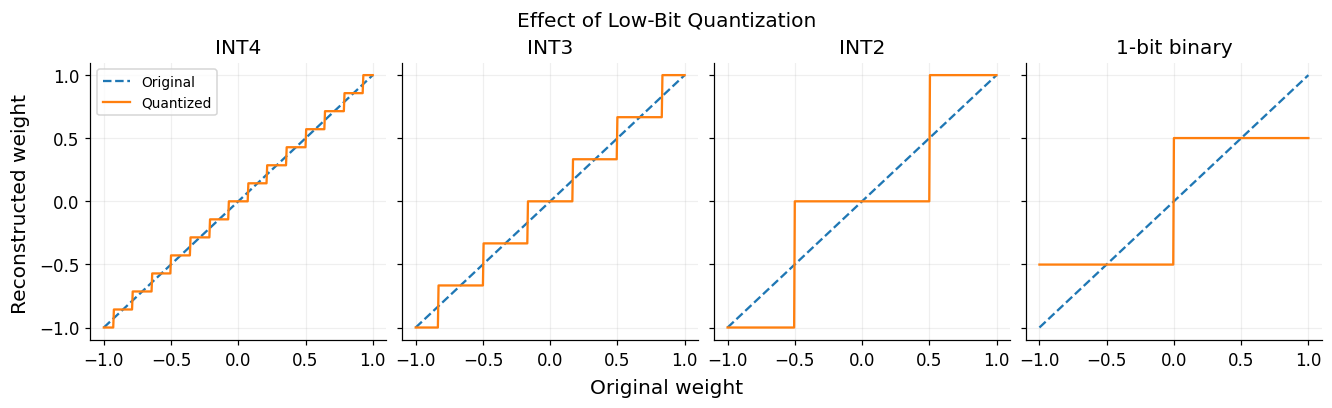

In [31]:
# Visualize low-bit quantization

grid = torch.linspace(-1, 1, 401)

fig, axes = plt.subplots(
    1, 4,
    figsize=(12, 3.6),
    sharex=True,
    sharey=True,
    layout="constrained"
)

for bits, ax in zip((4, 3, 2, 1), axes):

    if bits == 1:
        scale = grid.abs().mean()
        reconstructed = torch.where(
            grid >= 0,
            scale,
            -scale
        )

    else:
        qmin = -(2 ** (bits - 1))
        qmax = 2 ** (bits - 1) - 1

        scale = grid.abs().max() / qmax

        quantized = torch.round(grid / scale)
        quantized = torch.clamp(quantized, qmin, qmax)

        reconstructed = quantized * scale

    ax.plot(
        grid,
        grid,
        linestyle="--",
        label="Original"
    )

    ax.plot(
        grid,
        reconstructed,
        label="Quantized"
    )

    ax.set_title(
        "1-bit binary"
        if bits == 1
        else f"INT{bits}"
    )

    ax.grid(alpha=0.2)


axes[0].legend(fontsize=9)

fig.suptitle(
    "Effect of Low-Bit Quantization"
)

fig.supxlabel("Original weight")
fig.supylabel("Reconstructed weight")

plt.show()

### 5.6 Measure the effect of reduced-precision weights

We compare the quantized weights with the original FP32 weights using **mean absolute weight error (MAE)**. FP16 should introduce very little numerical error, while increasingly aggressive low-bit quantization generally produces larger weight changes.

INT8 is evaluated separately because PyTorch's native dynamic INT8 quantization replaces `nn.Linear` layers with quantized modules whose weights are stored differently.

In [32]:
weight_errors = {}

for label in ("FP16", "INT4", "INT3", "INT2", "INT1"):
    model = quantization_models[label]

    absolute_error = 0.0
    number_of_weights = 0

    for original_layer, quantized_layer in zip(
        fp32_reference.modules(),
        model.modules()
    ):
        if isinstance(original_layer, nn.Linear):
            original = original_layer.weight.detach().float()
            quantized = quantized_layer.weight.detach().float()

            absolute_error += (
                original - quantized
            ).abs().sum().item()

            number_of_weights += original.numel()

    weight_errors[label] = absolute_error / number_of_weights

    print(
        f"{label}: mean absolute weight error = "
        f"{weight_errors[label]:.6f}"
    )

FP16: mean absolute weight error = 0.000007
INT4: mean absolute weight error = 0.008248
INT3: mean absolute weight error = 0.016355
INT2: mean absolute weight error = 0.027615
INT1: mean absolute weight error = 0.026894


### 5.7 Evaluate the Quantized Models

We now evaluate every model on the **same validation set** so that the effect of quantization can be compared fairly.

For each model, we report:

- **Accuracy** - percentage of correctly classified validation samples.
- **Macro F1-score** - F1-score calculated independently for each activity class and then averaged.
- **Loss** - cross-entropy loss on the validation set.

FP16 requires FP16 inputs, while FP32 and the integer-quantized models use FP32 inputs. All models are evaluated on exactly the same validation samples.

In [33]:
quantization_results = []

for label, model in quantization_models.items():

    input_dtype = (
        torch.float16
        if label == "FP16"
        else torch.float32
    )

    metrics = evaluate_model(
        model,
        quant_X_val,
        quant_y_val,
        input_dtype=input_dtype
    )

    quantization_results.append({
        "version": label,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "loss": metrics["loss"],
    })

    print(
        f"{label:5s} | "
        f"Accuracy: {metrics['accuracy']:.2%} | "
        f"F1: {metrics['macro_f1']:.4f} | "
        f"Loss: {metrics['loss']:.4f}"
    )

FP32  | Accuracy: 96.67% | F1: 0.9631 | Loss: 0.1000
FP16  | Accuracy: 96.67% | F1: 0.9631 | Loss: 0.1000
INT8  | Accuracy: 96.78% | F1: 0.9642 | Loss: 0.1018
INT4  | Accuracy: 96.39% | F1: 0.9599 | Loss: 0.1130
INT3  | Accuracy: 92.39% | F1: 0.9208 | Loss: 0.1667


INT2  | Accuracy: 75.90% | F1: 0.7647 | Loss: 0.5595


INT1  | Accuracy: 80.12% | F1: 0.7844 | Loss: 0.5305


##### Compare Validation Accuracy

The following plot compares the validation accuracy of all quantized models on the same validation set. The dashed line represents the original FP32 baseline, making it easy to see how different levels of quantization affect model performance.

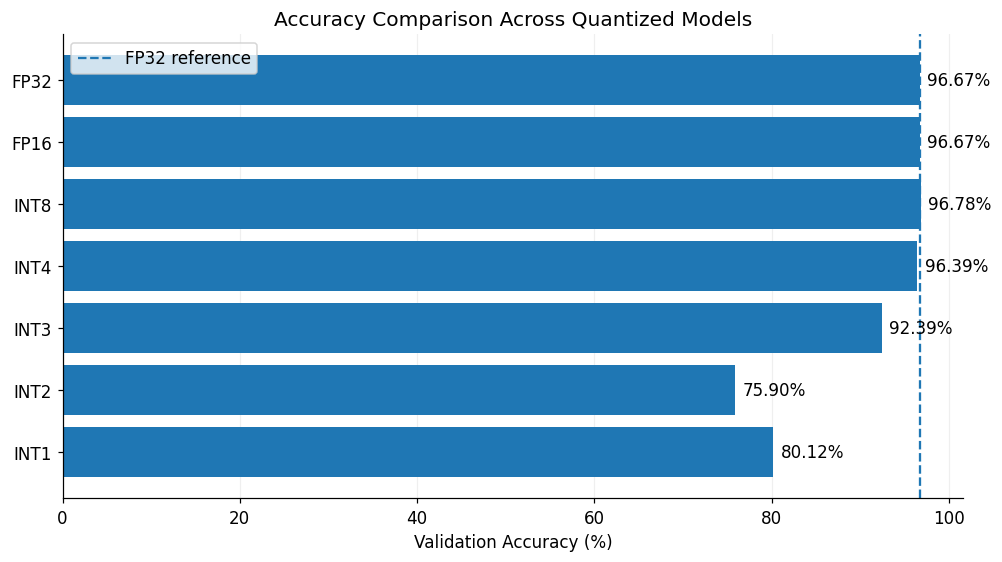

In [34]:
labels = [row["version"] for row in quantization_results]
accuracies = [100 * row["accuracy"] for row in quantization_results]

fig, ax = plt.subplots(
    figsize=(9, 5),
    layout="constrained"
)

bars = ax.barh(labels, accuracies)

ax.bar_label(
    bars,
    labels=[f"{value:.2f}%" for value in accuracies],
    padding=5
)

# FP32 reference
ax.axvline(
    accuracies[0],
    linestyle="--",
    label="FP32 reference"
)

ax.invert_yaxis()
ax.set_xlabel("Validation Accuracy (%)")
ax.set_title("Accuracy Comparison Across Quantized Models")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
ax.legend()

plt.show()

### 5.8 Measure Prediction Latency

Quantization can affect not only model accuracy but also inference speed. We therefore measure the prediction latency of each model using the same single validation sample.

Each model is first warmed up and then evaluated over multiple repeated predictions. We report the **median latency per prediction in milliseconds**.

> **Note:** INT4, INT3, INT2, and INT1 use reconstructed floating-point weights in this notebook. Their latency therefore represents standard PyTorch floating-point execution, not native low-bit hardware acceleration.

In [35]:
timing_labels = list(quantization_models.keys())

timings = {}

for label in timing_labels:
    model = quantization_models[label]

    input_dtype = (
        torch.float16
        if label == "FP16"
        else torch.float32
    )

    sample = quant_X_val[:1].to(input_dtype)

    # Warm-up
    with torch.inference_mode():
        for _ in range(100):
            model(sample)

    # Measure latency
    measurements = []

    with torch.inference_mode():
        for _ in range(20):

            start = time.perf_counter()

            for _ in range(200):
                model(sample)

            elapsed = time.perf_counter() - start

            measurements.append(
                elapsed * 1000 / 200
            )

    timings[label] = float(
        np.median(measurements)
    )


for label, latency in timings.items():
    print(
        f"{label:5s} | "
        f"Latency: {latency:.4f} ms"
    )

FP32  | Latency: 0.0438 ms
FP16  | Latency: 0.1013 ms
INT8  | Latency: 0.4588 ms
INT4  | Latency: 0.1044 ms
INT3  | Latency: 0.1306 ms
INT2  | Latency: 0.0434 ms
INT1  | Latency: 0.0543 ms


##### Compare Prediction Latency

The following plot compares the median prediction latency of all model versions using a single input sample.

FP32, FP16, and INT8 use their corresponding execution paths. INT4, INT3, INT2, and INT1 use reconstructed floating-point weights, so their measurements represent standard PyTorch floating-point execution rather than native low-bit acceleration.

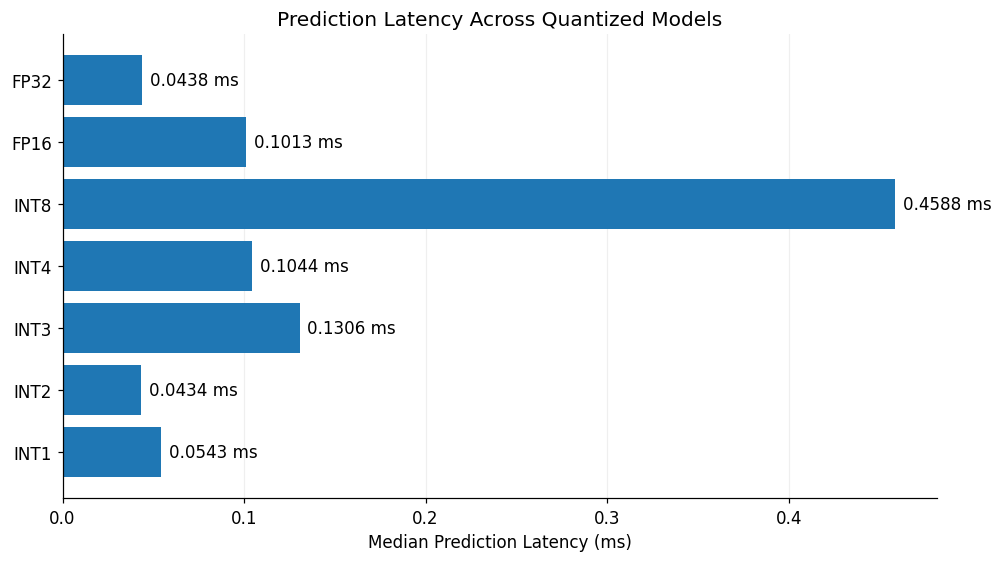

In [36]:
labels = list(timings.keys())
latencies = list(timings.values())

fig, ax = plt.subplots(
    figsize=(9, 5),
    layout="constrained"
)

bars = ax.barh(labels, latencies)

ax.bar_label(
    bars,
    labels=[f"{value:.4f} ms" for value in latencies],
    padding=5
)

ax.invert_yaxis()
ax.set_xlabel("Median Prediction Latency (ms)")
ax.set_title("Prediction Latency Across Quantized Models")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.show()

### What this experiment shows

- **The INT8 slowdown is a fixed-overhead effect, not a bug.** When each call does very little matrix work, measuring, quantizing and dequantizing activations costs more than the INT8 multiplication saves.
- **More work per call reverses it.** INT8 catches up and overtakes FP32 as the batch or layer grows. The crossover point depends on the CPU, the quantization engine and the PyTorch version, so read it from your own table.
- **Edge lesson:** a real edge device usually processes **one window at a time** with a **small model**, the exact case where dynamic INT8 helps least. Speed gains then need static quantization (activation ranges fixed in advance), fused operators, or a runtime and hardware with native integer kernels. The saved file is still about 3.8× smaller, which can matter more on the device than latency.
- **Engine matters.** Different engines (`x86`, `fbgemm`, `onednn`, `qnnpack`) have different per-call overhead. Compare the engine printed above with the supported list.

**Ask students:** A phone classifies one window every 1.28 s (50% overlap). Is 0.1 ms vs 0.02 ms per prediction important for that application? Which metric would you optimize first: latency, file size, or energy?

### Reading the observed results

In the verified run, FP16 preserved validation accuracy, and INT4 weight-only conversion produced a small accuracy change. INT8's tiny accuracy increase does not establish a general improvement.

**Why can INT1 outperform INT2 here?** The binary recipe uses a mean-absolute-weight scale, while the affine INT2 recipe uses extrema to choose its range. They are different quantizers. Large weights can stretch the affine range and leave coarse resolution for the many small weights. The observed weight-error and accuracy values therefore need not improve monotonically across these different recipes. This is not evidence that binary models are generally better than 2-bit models.

**Why was INT8 slower here?** We measured a small network with one input window per call. Quantization and operator overhead can outweigh savings in matrix multiplication; the result also depends on the backend and CPU. Sections 4.13 and 4.14 test this explanation directly by increasing the work per call. Repeating the experiment on target hardware can still give a different result.

The live table is the source of truth after a rerun; timing values can change.


### 5.9 What Did We Learn?

The quantization experiment shows that reducing numerical precision does not affect all models in the same way.

- **FP16 and INT8** preserved almost the same validation accuracy as FP32.

- **INT4** also retained most of the original model accuracy.

- More aggressive quantization with **INT3, INT2, and INT1** caused larger accuracy degradation.

- INT1 can outperform INT2 because they use different quantization methods; fewer bits do not automatically guarantee lower accuracy.

- Quantization does not automatically make inference faster. In this small model, dynamic INT8 was slower because its quantization overhead was larger than the computational savings.

- INT4, INT3, INT2, and INT1 use reconstructed floating-point weights in this notebook, so their measured latency does **not** represent native low-bit hardware execution.

These results are specific to this model, dataset, quantization method, and hardware. Different models or quantization techniques may produce different accuracy and latency trade-offs.

**Questions to consider:**

1. At what point did reducing precision cause a substantial accuracy drop?

2. Which model would you choose if maintaining accuracy were the main priority?

---

## 6. Pruning: Learn by Removing Weights

**Question:** How many of the model's parameters can we remove while maintaining good prediction accuracy?

**Pruning** removes selected weights from a neural network by setting them to zero. A common approach is **magnitude pruning**, where weights with the smallest absolute values are removed first because they are assumed to contribute less to the model's predictions.

### Key Ideas

| Term | Meaning |
|---|---|
| **Sparsity** | Fraction of weights that are zero. For example, 70% sparsity means 70% of the weights are removed. |
| **Unstructured pruning** | Removes individual weights from the network, producing scattered zeros while keeping the original layer shapes. |
| **Structured pruning** | Removes structured groups of weights, such as complete neurons or channels. |
| **Magnitude pruning** | Uses the absolute value \|w\| to decide which weights to remove. Smaller weights are pruned first. |
| **Mask** | A binary tensor where 1 means keep the weight and 0 means prune it. |
| **Global pruning** | Selects weights for pruning across all layers together rather than pruning the same percentage from every layer. |

### What We Do Here

1. Start from the original **FP32 baseline model**, not a quantized model.
2. Apply magnitude-based unstructured pruning at different sparsity levels.
3. Evaluate each pruned model on the same validation set.
4. Examine how increasing sparsity affects model accuracy.
5. Measure prediction latency to see whether introducing zeros automatically makes inference faster.

> **Important:** Setting a weight to zero does not automatically reduce model size or inference time. A zero stored inside a normal dense FP32 tensor still occupies memory and is processed by standard dense operations.

### 6.1 Prepare the FP32 Model for Pruning

We begin again from the original FP32 baseline so that the pruning experiment is independent of the quantization experiment.

In [37]:
PRUNE_DIR = Path("pruning_artifacts")
PRUNE_DIR.mkdir(exist_ok=True)

# Start again from the original FP32 model
prune_reference = nn.Sequential(
    nn.Linear(561, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 6)
).eval()

prune_reference.load_state_dict(
    torch.load(
        "baseline_artifacts/baseline_fp32.pt",
        map_location="cpu",
        weights_only=True
    )
)

# Use the same validation split
prune_split = np.load(
    "baseline_artifacts/participant_split.npz"
)

prune_val_idx = prune_split["val_idx"]

prune_X_val = torch.from_numpy(
    X_train[prune_val_idx]
)

prune_y_val = torch.from_numpy(
    y_train[prune_val_idx]
)

# Evaluate the original model
reference_prune_metrics = evaluate_model(
    prune_reference,
    prune_X_val,
    prune_y_val
)

# Count weights that can be pruned
linear_layers = [
    layer
    for layer in prune_reference.modules()
    if isinstance(layer, nn.Linear)
]

total_weights = sum(
    layer.weight.numel()
    for layer in linear_layers
)

total_biases = sum(
    layer.bias.numel()
    for layer in linear_layers
)

print(
    f"FP32 validation accuracy: "
    f"{reference_prune_metrics['accuracy']:.2%}"
)

print(
    f"Prunable weights: {total_weights:,} | "
    f"Biases kept: {total_biases:,}"
)

FP32 validation accuracy: 96.67%
Prunable weights: 80,384 | Biases kept: 198


### 6.2 Look at the Weights Before Pruning

Magnitude pruning removes weights with the smallest absolute values first. Before pruning, we examine the distribution of weight magnitudes in the trained model.

If many weights are close to zero, this suggests that some weights may be removed with only a small effect on the model.

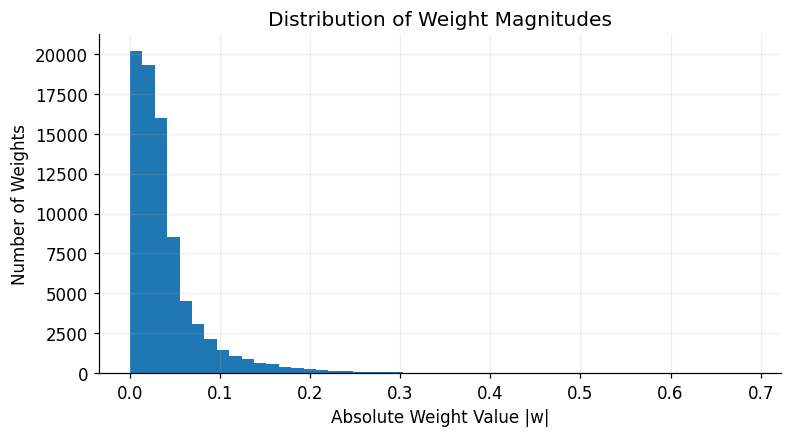

Number of weights: 80,384
Mean |w|: 0.0402
Median |w|: 0.0280


In [38]:
all_weights = torch.cat([
    layer.weight.detach().abs().flatten()
    for layer in linear_layers
])

plt.figure(figsize=(8, 4))

plt.hist(
    all_weights.numpy(),
    bins=50
)

plt.xlabel("Absolute Weight Value |w|")
plt.ylabel("Number of Weights")
plt.title("Distribution of Weight Magnitudes")
plt.grid(alpha=0.2)

plt.show()

print(f"Number of weights: {len(all_weights):,}")
print(f"Mean |w|: {all_weights.mean():.4f}")
print(f"Median |w|: {all_weights.median():.4f}")

**What to notice:** Most weights have relatively small absolute values, while only a small number have large magnitudes. Magnitude pruning uses this distribution by removing the smallest-magnitude weights first.

**Ask students:** If many weights are close to zero, how much can we prune before the model's accuracy starts to decrease significantly?

### 6.3 How Does Magnitude Pruning Work?

Before pruning the full model, consider a small example.

Magnitude pruning follows a simple idea:

1. Calculate the absolute value of each weight.
2. Find the weights with the smallest magnitudes.
3. Set those weights to zero.

The following example removes **50% of the weights** from a small weight matrix.

In [39]:
toy_weights = torch.tensor([
    [ 0.80, -0.05,  0.30, -0.60],
    [-0.02,  0.45, -0.90,  0.10],
    [ 0.25, -0.15,  0.01,  0.70]
])

sparsity = 0.50

# Calculate weight magnitudes
magnitudes = toy_weights.abs()

# Number of weights to remove
num_to_prune = round(
    sparsity * toy_weights.numel()
)

# Find the smallest weights
smallest_indices = torch.topk(
    magnitudes.flatten(),
    num_to_prune,
    largest=False
).indices

# Create pruning mask
mask = torch.ones_like(
    toy_weights.flatten()
)

mask[smallest_indices] = 0
mask = mask.reshape(toy_weights.shape)

# Apply pruning
pruned_weights = toy_weights * mask

print("Original weights:")
print(toy_weights)

print("\nPruning mask:")
print(mask)

print("\nPruned weights:")
print(pruned_weights)

print(
    f"\nSparsity achieved: "
    f"{(pruned_weights == 0).float().mean():.0%}"
)

Original weights:
tensor([[ 0.8000, -0.0500,  0.3000, -0.6000],
        [-0.0200,  0.4500, -0.9000,  0.1000],
        [ 0.2500, -0.1500,  0.0100,  0.7000]])

Pruning mask:
tensor([[1., 0., 1., 1.],
        [0., 1., 1., 0.],
        [0., 0., 0., 1.]])

Pruned weights:
tensor([[ 0.8000, -0.0000,  0.3000, -0.6000],
        [-0.0000,  0.4500, -0.9000,  0.0000],
        [ 0.0000, -0.0000,  0.0000,  0.7000]])

Sparsity achieved: 50%


**What happened?** The six weights with the smallest absolute values were replaced by zero, while the six larger weights were preserved.

The same principle can now be applied to the thousands of weights in our trained model.

### 6.4 Visualize Unstructured Pruning

Unstructured pruning removes individual weights while keeping the original layer dimensions unchanged.

The plots below show a small part of the first linear layer before pruning and after applying **50%** and **90% sparsity**. Pruned weights appear as white cells.

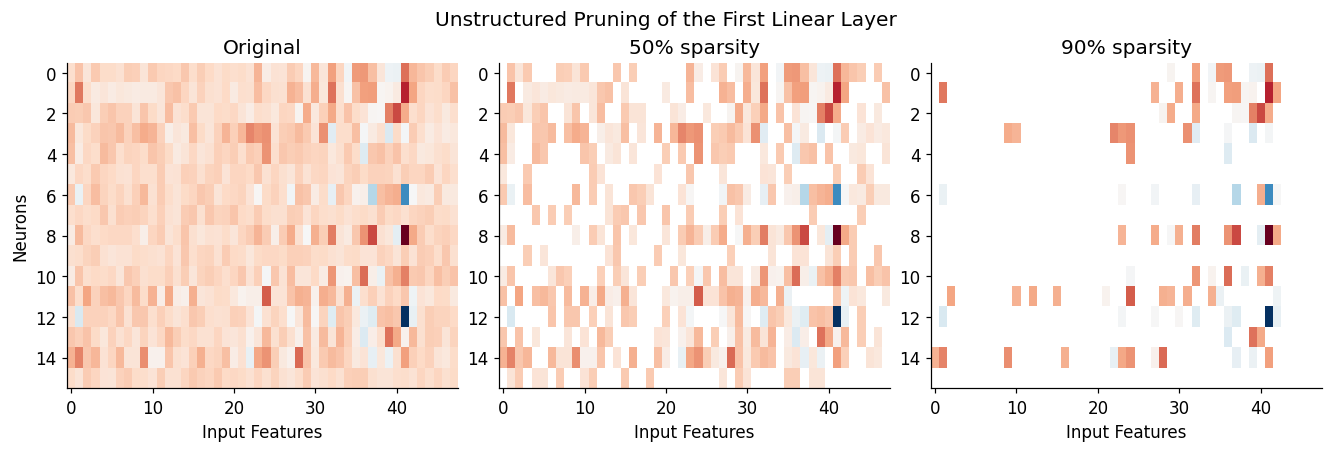

In [40]:
# Create pruned versions of the model
model_50 = prune_unstructured(
    prune_reference,
    sparsity=0.50
)

model_90 = prune_unstructured(
    prune_reference,
    sparsity=0.90
)

models_to_show = [
    ("Original", prune_reference),
    ("50% sparsity", model_50),
    ("90% sparsity", model_90)
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    layout="constrained"
)

for ax, (title, model) in zip(axes, models_to_show):

    weights = model[0].weight.detach()[:16, :48]

    # Hide zero (pruned) weights
    shown = np.ma.masked_where(
        weights.numpy() == 0,
        weights.numpy()
    )

    image = ax.imshow(
        shown,
        cmap="RdBu_r",
        aspect="auto"
    )

    ax.set_facecolor("white")
    ax.set_title(title)
    ax.set_xlabel("Input Features")

axes[0].set_ylabel("Neurons")

fig.suptitle(
    "Unstructured Pruning of the First Linear Layer"
)

plt.show()

**What to notice:** As sparsity increases, more individual weights become zero. However, the layer still has the same number of neurons and input features. Unstructured pruning therefore creates a sparse weight matrix rather than automatically creating a smaller layer.

### 6.5 Create Models with Different Sparsity Levels

We now apply global magnitude pruning to the trained FP32 model at different sparsity levels.

Each pruned model is created independently from the original FP32 model. This allows us to compare how increasing sparsity affects model performance.

We test sparsity levels from **10% to 90%**, plus an extreme **95%** case.

In [41]:
SPARSITY_LEVELS = (
    0.10, 0.20, 0.30, 0.40, 0.50,
    0.60, 0.70, 0.80, 0.90, 0.95
)

pruned_models = {}

for sparsity in SPARSITY_LEVELS:

    model = prune_unstructured(
        prune_reference,
        sparsity=sparsity
    )

    pruned_models[sparsity] = model

    print(
        f"Target: {sparsity:.0%} | "
        f"Measured: {get_sparsity(model):.2%}"
    )

Target: 10% | Measured: 10.00%
Target: 20% | Measured: 20.00%
Target: 30% | Measured: 30.00%
Target: 40% | Measured: 40.00%
Target: 50% | Measured: 50.00%
Target: 60% | Measured: 60.00%
Target: 70% | Measured: 70.00%
Target: 80% | Measured: 80.00%
Target: 90% | Measured: 90.00%
Target: 95% | Measured: 95.00%


### 6.6 Does Pruning Automatically Reduce Model Size?

Unstructured pruning sets selected weights to zero, but the weight matrices keep their original dimensions.

For example, a `561 × 128` FP32 weight matrix still contains the same number of stored values even if 90% of them are zero. Therefore, saving the model as a normal dense PyTorch model does not provide a proportional reduction in file size.

To obtain real storage savings, the model would need a **sparse storage format** that stores only the non-zero values and information about their positions.

Similarly, faster inference generally requires hardware and software with efficient **sparse computation support**.

In this notebook, we focus on the effect of pruning on **sparsity, prediction accuracy, and latency**, rather than implementing specialized sparse storage formats.

### 6.7 Evaluate the Pruned Models

We now evaluate every pruned model on the **same validation set**.

No fine-tuning has been performed yet, so the results show the direct effect of removing weights from the trained FP32 model.

For each sparsity level, we report:

- **Measured sparsity** - percentage of weights equal to zero.
- **Non-zero weights** - number of weights remaining after pruning.
- **Accuracy** - percentage of correctly classified validation samples.
- **Macro F1-score** - average F1-score across the six activity classes.
- **Loss** - cross-entropy loss on the validation set.
- **Accuracy change** - difference from the original FP32 model in percentage points.

In [42]:
pruning_results = []

# Add the original FP32 model
pruning_results.append({
    "version": "FP32",
    "sparsity": 0.0,
    "nonzero_weights": total_weights,
    **reference_prune_metrics
})

# Evaluate every pruned model
for sparsity in SPARSITY_LEVELS:

    model = pruned_models[sparsity]

    metrics = evaluate_model(
        model,
        prune_X_val,
        prune_y_val
    )

    nonzero_weights = sum(
        (layer.weight != 0).sum().item()
        for layer in model.modules()
        if isinstance(layer, nn.Linear)
    )

    pruning_results.append({
        "version": f"{sparsity:.0%}",
        "sparsity": get_sparsity(model),
        "nonzero_weights": nonzero_weights,
        **metrics
    })


# Accuracy change relative to FP32
reference_accuracy = reference_prune_metrics["accuracy"]

for row in pruning_results:
    row["accuracy_change_pp"] = (
        100 * (row["accuracy"] - reference_accuracy)
    )


# Display results
lines = [
    "| Version | Sparsity | Non-zero Weights | Accuracy | Δ vs FP32 | Macro F1 | Loss |",
    "|---|---:|---:|---:|---:|---:|---:|"
]

for row in pruning_results:
    lines.append(
        f"| {row['version']} "
        f"| {row['sparsity']:.1%} "
        f"| {row['nonzero_weights']:,} "
        f"| {row['accuracy']:.2%} "
        f"| {row['accuracy_change_pp']:+.2f} pp "
        f"| {row['macro_f1']:.4f} "
        f"| {row['loss']:.4f} |"
    )

display(
    Markdown("\n".join(lines))
)

| Version | Sparsity | Non-zero Weights | Accuracy | Δ vs FP32 | Macro F1 | Loss |
|---|---:|---:|---:|---:|---:|---:|
| FP32 | 0.0% | 80,384 | 96.67% | +0.00 pp | 0.9631 | 0.1000 |
| 10% | 10.0% | 72,346 | 96.78% | +0.11 pp | 0.9642 | 0.1009 |
| 20% | 20.0% | 64,307 | 96.61% | -0.06 pp | 0.9623 | 0.1060 |
| 30% | 30.0% | 56,269 | 96.56% | -0.11 pp | 0.9615 | 0.1083 |
| 40% | 40.0% | 48,230 | 96.61% | -0.06 pp | 0.9625 | 0.1006 |
| 50% | 50.0% | 40,192 | 97.00% | +0.33 pp | 0.9671 | 0.0912 |
| 60% | 60.0% | 32,154 | 96.67% | +0.00 pp | 0.9641 | 0.0887 |
| 70% | 70.0% | 24,115 | 95.84% | -0.83 pp | 0.9564 | 0.1044 |
| 80% | 80.0% | 16,077 | 84.84% | -11.83 pp | 0.8534 | 0.3150 |
| 90% | 90.0% | 8,038 | 67.74% | -28.93 pp | 0.6692 | 0.7410 |
| 95% | 95.0% | 4,019 | 63.96% | -32.70 pp | 0.5962 | 1.1991 |

The model remains highly robust to pruning up to **60% sparsity**, with almost no loss in validation accuracy. Performance begins to decline at **70% sparsity** and drops substantially from **80% onward**, suggesting that roughly 60% of the weights can be removed without harming performance in this experiment.

### 6.8 Accuracy as Sparsity Increases

The following plot shows how validation accuracy changes as more weights are removed. The dashed line represents the original FP32 accuracy.

This helps identify how much pruning the model can tolerate before its performance begins to decrease substantially.

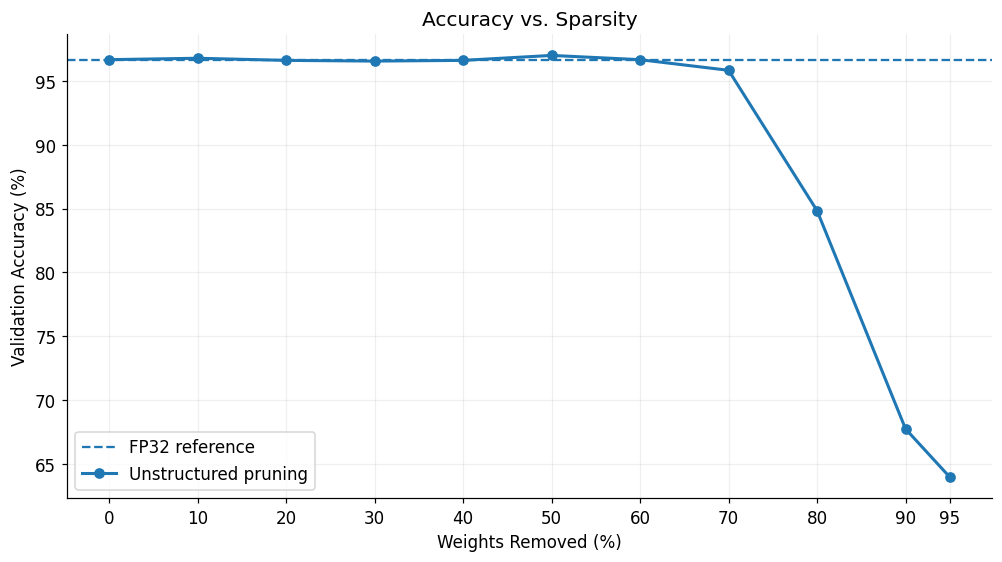

In [43]:
x_levels = [
    100 * row["sparsity"]
    for row in pruning_results
]

accuracies = [
    100 * row["accuracy"]
    for row in pruning_results
]

fig, ax = plt.subplots(
    figsize=(9, 5),
    layout="constrained"
)

# FP32 reference
ax.axhline(
    100 * reference_accuracy,
    linestyle="--",
    label="FP32 reference"
)

# Pruning results
ax.plot(
    x_levels,
    accuracies,
    marker="o",
    linewidth=2,
    label="Unstructured pruning"
)

ax.set_xticks(x_levels)

ax.set_xlabel("Weights Removed (%)")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Accuracy vs. Sparsity")

ax.grid(alpha=0.2)
ax.legend()

plt.show()

### 6.9 Storage Size as Sparsity Increases

Pruning creates more zero-valued weights, but the way the model is stored determines whether this actually reduces file size.

We compare three storage approaches:

- **Dense FP32:** stores every weight, including zeros.

- **CSR:** stores only non-zero values together with their positions.

- **Bitmask:** stores the non-zero values together with a compact mask indicating which weights remain.

As sparsity increases, the dense representation should remain approximately the same size, while sparse representations can become smaller.

In [44]:
# Estimate storage requirements for each sparsity level

storage_bytes = {}

for sparsity, model in pruned_models.items():

    dense_bytes = 0
    csr_bytes = 0
    bitmask_bytes = 0

    for layer in model.modules():

        if not isinstance(layer, nn.Linear):
            continue

        weight = layer.weight.detach()

        rows, cols = weight.shape
        total = weight.numel()
        nonzero = (weight != 0).sum().item()

        # Dense FP32: 4 bytes for every weight
        dense_bytes += 4 * total

        # CSR:
        # FP32 values + int16 column indices + int32 row pointers
        csr_bytes += (
            4 * nonzero
            + 2 * nonzero
            + 4 * (rows + 1)
        )

        # Bitmask:
        # 1 bit per original weight + FP32 non-zero values
        bitmask_bytes += (
            total / 8
            + 4 * nonzero
        )

    storage_bytes[sparsity] = {
        "dense": dense_bytes,
        "csr": csr_bytes,
        "bitmask": bitmask_bytes
    }

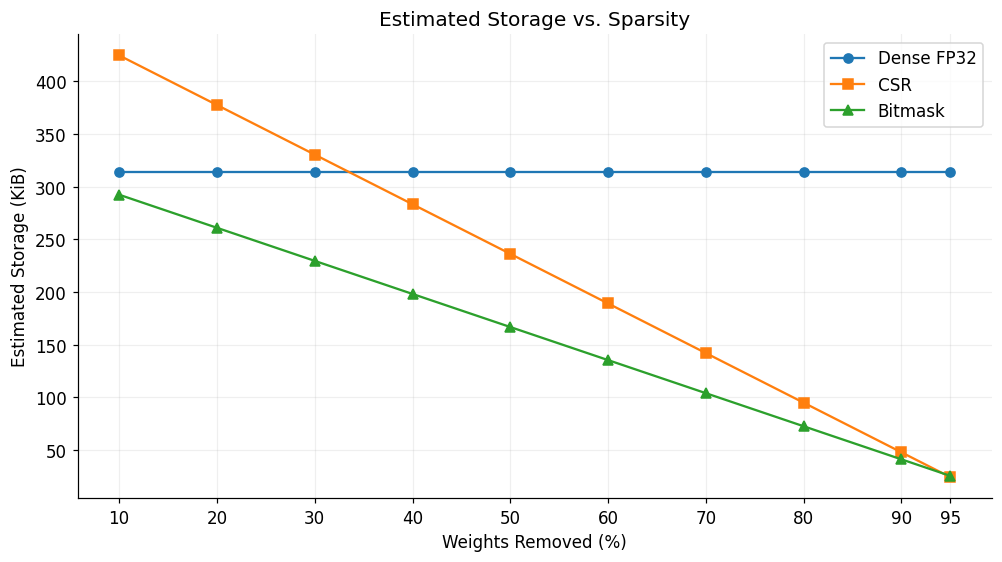

In [45]:
sparsity_percent = [
    100 * s
    for s in SPARSITY_LEVELS
]

dense_kib = [
    storage_bytes[s]["dense"] / 1024
    for s in SPARSITY_LEVELS
]

csr_kib = [
    storage_bytes[s]["csr"] / 1024
    for s in SPARSITY_LEVELS
]

bitmask_kib = [
    storage_bytes[s]["bitmask"] / 1024
    for s in SPARSITY_LEVELS
]

fig, ax = plt.subplots(
    figsize=(9, 5),
    layout="constrained"
)

ax.plot(
    sparsity_percent,
    dense_kib,
    marker="o",
    label="Dense FP32"
)

ax.plot(
    sparsity_percent,
    csr_kib,
    marker="s",
    label="CSR"
)

ax.plot(
    sparsity_percent,
    bitmask_kib,
    marker="^",
    label="Bitmask"
)

ax.set_xlabel("Weights Removed (%)")
ax.set_ylabel("Estimated Storage (KiB)")
ax.set_title("Estimated Storage vs. Sparsity")

ax.set_xticks(sparsity_percent)
ax.grid(alpha=0.2)
ax.legend()

plt.show()

As sparsity increases, dense FP32 storage remains unchanged, while CSR and bitmask representations become progressively smaller because they store only the remaining non-zero weights efficiently.

### 6.10 Does Pruning Make Predictions Faster?

Pruning removes weights by setting them to zero, but our models are still executed using standard dense `nn.Linear` layers.

This means that zero-valued weights are still included in the matrix multiplication. Therefore, increasing sparsity does not necessarily make inference faster.

We measure the prediction latency of each pruned model using the same single validation sample.

In [46]:
pruning_timings = {}

timing_models = {
    "FP32": prune_reference
}

for sparsity in SPARSITY_LEVELS:
    timing_models[f"{sparsity:.0%}"] = pruned_models[sparsity]


for label, model in timing_models.items():

    sample = prune_X_val[:1]

    # Warm-up
    with torch.inference_mode():
        for _ in range(100):
            model(sample)

    # Measure latency
    measurements = []

    with torch.inference_mode():
        for _ in range(20):

            start = time.perf_counter()

            for _ in range(200):
                model(sample)

            elapsed = time.perf_counter() - start

            measurements.append(
                elapsed * 1000 / 200
            )

    pruning_timings[label] = float(
        np.median(measurements)
    )


for label, latency in pruning_timings.items():
    print(
        f"{label:5s} | "
        f"Latency: {latency:.4f} ms"
    )

FP32  | Latency: 0.1109 ms
10%   | Latency: 0.0894 ms
20%   | Latency: 0.0504 ms
30%   | Latency: 0.0510 ms
40%   | Latency: 0.0455 ms
50%   | Latency: 0.0621 ms
60%   | Latency: 0.0771 ms
70%   | Latency: 0.0956 ms
80%   | Latency: 0.0547 ms
90%   | Latency: 0.0442 ms
95%   | Latency: 0.0574 ms


Pruning up to 60% preserves almost all accuracy, but prediction latency remains nearly unchanged because the pruned models still use standard dense operations that process zero weights.

### 6.11 Recover Accuracy with Fine-Tuning

So far, the pruned models have been evaluated **without additional training**. At high sparsity levels, removing many weights can substantially reduce accuracy.

Fine-tuning briefly trains the remaining weights so that the model can adapt to the removed connections.

During fine-tuning, the pruning mask is kept fixed so that weights that were set to zero cannot grow back.

We fine-tune each pruned model for **10 epochs** using a smaller learning rate of **1e-4**.

In [47]:
FINETUNE_EPOCHS = 10
FINETUNE_LR = 1e-4

prune_train_idx = prune_split["train_idx"]

finetune_dataset = TensorDataset(
    torch.from_numpy(X_train[prune_train_idx]),
    torch.from_numpy(y_train[prune_train_idx])
)

finetune_loader = DataLoader(
    finetune_dataset,
    batch_size=64,
    shuffle=True
)

In [48]:
finetuned_models = {}
finetune_results = []

for sparsity in SPARSITY_LEVELS:

    model = pruned_models[sparsity]

    before = evaluate_model(
        model,
        prune_X_val,
        prune_y_val
    )

    # Remember exactly which weights were pruned
    masks = {
        name: (module.weight != 0).float()
        for name, module in model.named_modules()
        if isinstance(module, nn.Linear)
    }

    finetuned_model, best_epoch = finetune_pruned_model(
        model,
        finetune_loader,
        prune_X_val,
        prune_y_val,
        masks=masks,
        epochs=10,
        lr=1e-4
    )

    after = evaluate_model(
        finetuned_model,
        prune_X_val,
        prune_y_val
    )

    measured_sparsity = get_sparsity(finetuned_model)

    finetuned_models[sparsity] = finetuned_model

    finetune_results.append({
        "sparsity": sparsity,
        "before_accuracy": before["accuracy"],
        "after_accuracy": after["accuracy"],
        "best_epoch": best_epoch
    })

    print(
        f"{sparsity:.0%} sparsity | "
        f"Before: {before['accuracy']:.2%} | "
        f"After: {after['accuracy']:.2%} | "
        f"Epoch: {best_epoch} | "
        f"Measured sparsity: {measured_sparsity:.2%}"
    )

10% sparsity | Before: 96.78% | After: 96.78% | Epoch: 0 | Measured sparsity: 10.00%


20% sparsity | Before: 96.61% | After: 96.61% | Epoch: 0 | Measured sparsity: 20.00%


30% sparsity | Before: 96.56% | After: 96.56% | Epoch: 0 | Measured sparsity: 30.00%


40% sparsity | Before: 96.61% | After: 96.61% | Epoch: 0 | Measured sparsity: 40.00%


50% sparsity | Before: 97.00% | After: 97.00% | Epoch: 0 | Measured sparsity: 50.00%


60% sparsity | Before: 96.67% | After: 96.67% | Epoch: 0 | Measured sparsity: 60.00%


70% sparsity | Before: 95.84% | After: 95.84% | Epoch: 0 | Measured sparsity: 70.00%


80% sparsity | Before: 84.84% | After: 96.00% | Epoch: 9 | Measured sparsity: 80.00%


90% sparsity | Before: 67.74% | After: 95.39% | Epoch: 10 | Measured sparsity: 90.00%


95% sparsity | Before: 63.96% | After: 93.23% | Epoch: 10 | Measured sparsity: 95.00%


**What to notice:** Fine-tuning is unnecessary at moderate sparsity levels, but at 80–95% sparsity it allows the remaining weights to adapt and recover much of the accuracy lost during aggressive pruning, while the original sparsity remains unchanged.

### 6.12 Before vs. After Fine-Tuning

The sparsity level remains unchanged during fine-tuning. Only the remaining non-zero weights are updated.

The following plot compares validation accuracy before and after fine-tuning.

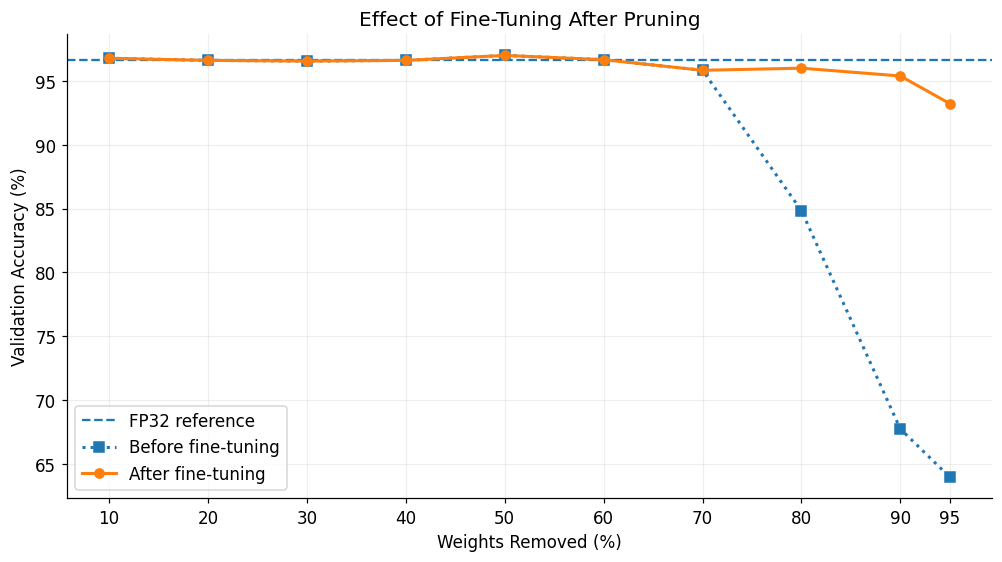

In [49]:
sparsity_percent = [
    100 * r["sparsity"]
    for r in finetune_results
]

before_accuracy = [
    100 * r["before_accuracy"]
    for r in finetune_results
]

after_accuracy = [
    100 * r["after_accuracy"]
    for r in finetune_results
]

fig, ax = plt.subplots(
    figsize=(9, 5),
    layout="constrained"
)

ax.axhline(
    100 * reference_accuracy,
    linestyle="--",
    label="FP32 reference"
)

ax.plot(
    sparsity_percent,
    before_accuracy,
    marker="s",
    linestyle=":",
    linewidth=2,
    label="Before fine-tuning"
)

ax.plot(
    sparsity_percent,
    after_accuracy,
    marker="o",
    linewidth=2,
    label="After fine-tuning"
)

ax.set_xticks(sparsity_percent)
ax.set_xlabel("Weights Removed (%)")
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Effect of Fine-Tuning After Pruning")
ax.grid(alpha=0.2)
ax.legend()

plt.show()

**What to notice:** Fine-tuning provides little benefit at moderate sparsity because the pruned models already perform well. At 80–95% sparsity, however, fine-tuning substantially recovers the accuracy lost after aggressive pruning while keeping the same sparsity.

---

## 7. Combine pruning and quantization

**Prune → fine-tune → quantize.** Reuse the models from sections 5 and 6.

Our rule: allow at most **1 percentage point** below FP32 validation accuracy. Choose the fewest bits among INT2–INT4 and the highest fine-tuned sparsity that meet this rule. These affine quantizers preserve zero; the binary quantizer does not.

The two choices may work well separately but fail together, so evaluate the combination again. Use validation data here.

### 7.1 Select the two ingredients

In [50]:
TOLERANCE_PP = 1.0
fp32_accuracy = reference_prune_metrics["accuracy"]
accuracy_limit = fp32_accuracy - TOLERANCE_PP / 100

quant_candidates = [
    row for row in quantization_results
    if row["version"] in ("INT2", "INT3", "INT4")
    and row["accuracy"] >= accuracy_limit
]
prune_candidates = [
    row for row in finetune_results
    if row["after_accuracy"] >= accuracy_limit
]
if not quant_candidates or not prune_candidates:
    raise ValueError("No eligible combination ingredients. Review the validation results first.")

best_quant = min(quant_candidates, key=lambda row: int(row["version"][3:]))
best_prune = max(prune_candidates, key=lambda row: row["sparsity"])
BEST_BITS = int(best_quant["version"][3:])
BEST_SPARSITY = best_prune["sparsity"]
best_pruned_model = finetuned_models[BEST_SPARSITY]

print(f"Minimum validation accuracy: {accuracy_limit:.2%}")
print(f"Selected: INT{BEST_BITS} and {BEST_SPARSITY:.0%} pruning + fine-tuning")

Minimum validation accuracy: 95.67%
Selected: INT4 and 80% pruning + fine-tuning


### 7.2 Check that zeros stay zero

Apply the same quantizer to a small example before using the full model.

In [51]:
toy_model = nn.Linear(6, 1, bias=False)
with torch.no_grad():
    toy_model.weight.copy_(torch.tensor([[0.42, 0.00, -0.31, 0.00, 0.06, -0.018]]))

toy_quantized = quantize_weights(toy_model, bits=BEST_BITS)
print("Before:", toy_model.weight.detach().numpy().round(4))
print("After: ", toy_quantized.weight.detach().numpy().round(4))
assert torch.all(toy_quantized.weight[toy_model.weight == 0] == 0)

Before: [[ 0.42   0.    -0.31   0.     0.06  -0.018]]
After:  [[ 0.438   0.     -0.292   0.      0.0487  0.    ]]


### 7.3 Quantize the fine-tuned pruned model

One function call combines the methods. Check that every pruned weight remains zero.

In [52]:
combo_lowbit_model = quantize_weights(best_pruned_model, bits=BEST_BITS)

for name, layer in best_pruned_model.named_modules():
    if isinstance(layer, nn.Linear):
        combined_weight = combo_lowbit_model.get_submodule(name).weight
        assert torch.all(combined_weight[layer.weight == 0] == 0)

combined_models = {
    "FP32": prune_reference,
    f"INT{BEST_BITS} only": quantization_models[best_quant["version"]],
    f"Pruned {BEST_SPARSITY:.0%} + fine-tuned": best_pruned_model,
    f"Pruned + INT{BEST_BITS}": combo_lowbit_model,
}
print(f"Sparsity after quantization: {get_sparsity(combo_lowbit_model):.2%}")

Sparsity after quantization: 80.00%


### 7.4 Compare validation accuracy

All four models use the same validation windows. A passing combination meets our chosen tolerance; it is not guaranteed to be the best possible pair.

In [53]:
combined_results = []
for label, model in combined_models.items():
    metrics = evaluate_model(model, prune_X_val, prune_y_val)
    combined_results.append({"model": label, **metrics})

lines = ["| Model | Validation accuracy | Loss | Change vs FP32 (pp) |",
         "|---|---:|---:|---:|"]
for row in combined_results:
    change = 100 * (row["accuracy"] - fp32_accuracy)
    lines.append(f"| {row['model']} | {row['accuracy']:.2%} | {row['loss']:.4f} | {change:+.2f} |")
display(Markdown("\n".join(lines)))

combination_passes = combined_results[-1]["accuracy"] >= accuracy_limit
print("Combined model meets tolerance:", combination_passes)

| Model | Validation accuracy | Loss | Change vs FP32 (pp) |
|---|---:|---:|---:|
| FP32 | 96.67% | 0.1000 | +0.00 |
| INT4 only | 96.39% | 0.1130 | -0.28 |
| Pruned 80% + fine-tuned | 96.00% | 0.1147 | -0.67 |
| Pruned + INT4 | 95.95% | 0.1185 | -0.72 |

Combined model meets tolerance: True


### 7.5 Estimate storage savings

Compare hypothetical packed payloads: weights, FP32 biases, row scales/zero points for low-bit weights, and a 1-bit position mask for pruning. Container overhead is excluded. These are **estimates, not saved file sizes or runtime memory**. The current low-bit models execute with reconstructed FP32 weights.

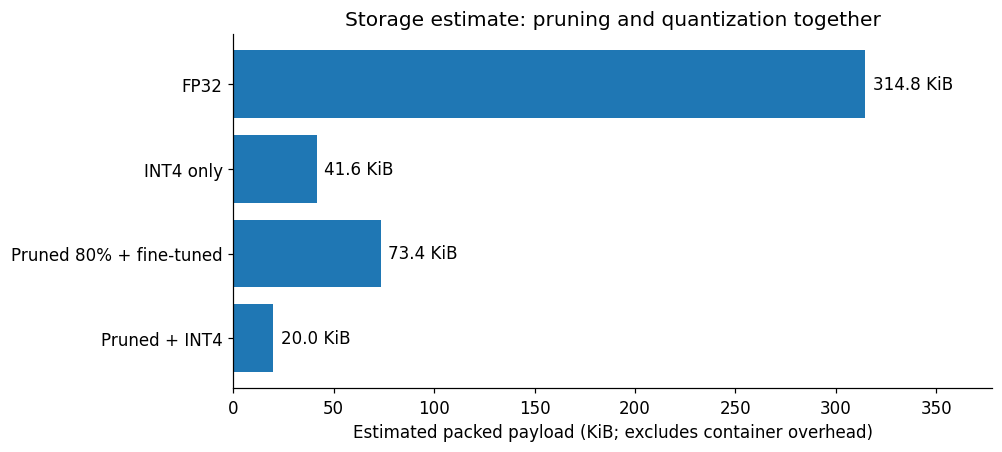

In [54]:
def estimated_payload_bytes(model, bits=32, sparse=False):
    total = 0
    for layer in model.modules():
        if not isinstance(layer, nn.Linear):
            continue
        weight = layer.weight.detach()
        count = int(weight.count_nonzero()) if sparse else weight.numel()
        total += (count * bits + 7) // 8
        total += layer.bias.numel() * 4
        if sparse:
            total += (weight.numel() + 7) // 8  # Position mask
        if bits < 32:
            total += weight.shape[0] * 8  # FP32 scale and zero point per row
    return total

storage_settings = [(32, False), (BEST_BITS, False), (32, True), (BEST_BITS, True)]
for row, model, (bits, sparse) in zip(combined_results, combined_models.values(), storage_settings):
    row["estimated_payload_bytes"] = estimated_payload_bytes(model, bits, sparse)

names = list(combined_models)
sizes = [row["estimated_payload_bytes"] / 1024 for row in combined_results]
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
bars = ax.barh(names, sizes)
ax.bar_label(bars, fmt="%.1f KiB", padding=5)
ax.invert_yaxis()
ax.set_xlim(0, max(sizes) * 1.2)
ax.set_xlabel("Estimated packed payload (KiB; excludes container overhead)")
ax.set_title("Storage estimate: pruning and quantization together")
plt.show()

### 7.6 Measure prediction latency separately

Measure one-window CPU inference after warm-up, using the median of 20 blocks. Rotate model order between blocks. Smaller storage does not guarantee faster prediction: all four models here execute dense FP32 operations.

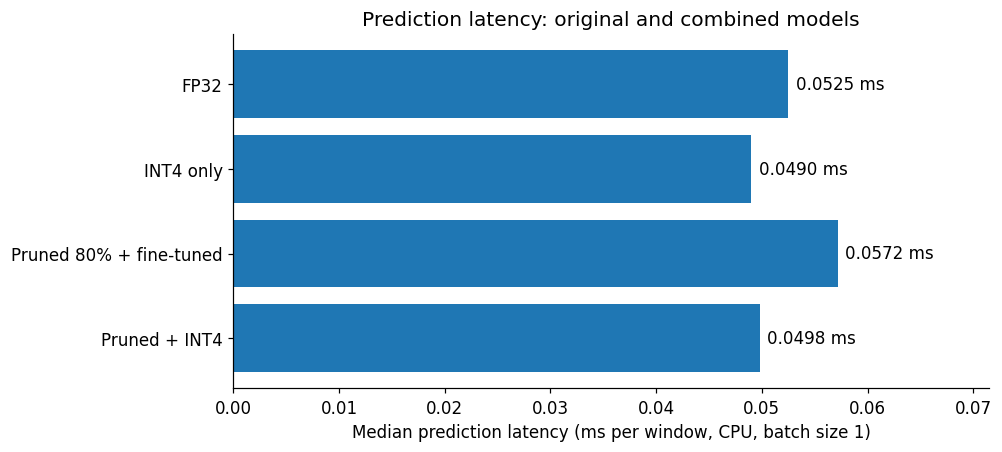

In [55]:
sample = prune_X_val[:1]
combined_timings = {label: [] for label in combined_models}
rng = np.random.default_rng(42)

with torch.inference_mode():
    for model in combined_models.values():
        for _ in range(100):
            model(sample)
    for _ in range(20):
        for label in rng.permutation(list(combined_models)):
            model = combined_models[label]
            start = time.perf_counter()
            for _ in range(200):
                model(sample)
            combined_timings[label].append((time.perf_counter() - start) * 1000 / 200)

latencies = [float(np.median(combined_timings[label])) for label in combined_models]
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
bars = ax.barh(list(combined_models), latencies)
ax.bar_label(bars, fmt="%.4f ms", padding=5)
ax.invert_yaxis()
ax.set_xlim(0, max(latencies) * 1.25)
ax.set_xlabel("Median prediction latency (ms per window, CPU, batch size 1)")
ax.set_title("Prediction latency: original and combined models")
plt.show()

### 7.7 What did we learn?

- Pruning removes weights; quantization reduces the precision of those kept.
- Check combined accuracy and zero preservation after applying both methods.
- Packed storage savings require an appropriate export format. Dense FP32 execution does not use those savings automatically.
- Read the measured latency plot independently of the storage estimate. Freeze model choices before final test evaluation.

### Discuss with students

1. Why can two acceptable methods fail when combined?
2. Why do the position mask and quantization metadata reduce ideal storage savings?
3. Why can a smaller representation have similar prediction latency?

---

## 8. Deploy and compare the selected model with ONNX

**Goal:** take the combined model selected in section 7, export it, verify its predictions, and measure the actual deployment files.

ONNX stores a computation graph, its weights, and input/output definitions. ONNX Runtime executes that graph. Exporting changes the deployment format; it does not by itself reduce weight precision or remove stored zeros.

We reuse **`export_onnx()`**, **`create_onnx_session()`**, and **`evaluate_model()`** from section 1. The model and settings come from **`combo_lowbit_model`**, **`best_pruned_model`**, **`BEST_BITS`**, and **`BEST_SPARSITY`** in section 7.

| Step | Purpose |
|---|---|
| 8.1 | Check prerequisites and define ONNX evaluation |
| 8.2 | Export the selected model with the existing helper |
| 8.3 | Verify logits, labels, and metrics against PyTorch |
| 8.4 | Store the same low-bit weights in a UINT4 ONNX container |
| 8.5 | Compare ONNX Runtime's own INT8 and INT4 quantizers |
| 8.6–8.7 | Measure actual file sizes and CPU latency |
| 8.8 | Classify new feature vectors with a reusable predictor |
| 8.9 | Interpret the measured results |

Section 7 reports **estimated packed payloads**. Here we measure **real saved files**, including format overhead. All model comparisons use the same validation data. Keep the official test set for section 9.

### 8.1 Prepare the deployment experiment

Run setup and sections through 7 first. ONNX dependencies are already handled by the setup cells. No model is trained here. We add an ONNX evaluator because `evaluate_model()` expects a PyTorch model; both evaluators report accuracy, macro F1, and cross-entropy loss.

In [56]:
required_names = (
    "export_onnx", "create_onnx_session", "evaluate_model",
    "combo_lowbit_model", "best_pruned_model", "prune_reference",
    "prune_X_val", "prune_y_val", "BEST_BITS", "BEST_SPARSITY",
    "activity_names", "combination_passes"
)
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Run the earlier sections first. Missing: {missing}")
if not combination_passes:
    raise ValueError("The section 7 combination failed the validation tolerance; review it before deployment.")
if BEST_BITS not in (2, 3, 4):
    raise ValueError("This UINT4 storage example supports the INT2/INT3/INT4 candidates from section 7.")

ONNX_DIR = Path("onnx_artifacts")
ONNX_DIR.mkdir(exist_ok=True)
final_torch_model = copy.deepcopy(combo_lowbit_model).cpu().eval()
ACTIVITIES = list(activity_names)
pruning_tag = f"pruned{round(100 * BEST_SPARSITY)}"
print(f"Selected model: {BEST_SPARSITY:.0%} pruning + INT{BEST_BITS}")
print(f"Validation windows: {len(prune_y_val):,}")

def evaluate_onnx(session, X, y, batch_size=64):
    """Evaluate ONNX logits on explicitly supplied data, using the PyTorch metric definitions."""
    features = X.detach().cpu().numpy().astype(np.float32, copy=False)
    labels = y.detach().cpu()
    input_name = session.get_inputs()[0].name
    logits = np.concatenate([
        session.run(None, {input_name: features[start:start + batch_size]})[0]
        for start in range(0, len(labels), batch_size)
    ])
    predictions = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels.numpy(), predictions),
        "macro_f1": f1_score(labels.numpy(), predictions, average="macro"),
        "loss": nn.functional.cross_entropy(torch.from_numpy(logits), labels).item(),
        "logits": logits
    }

Selected model: 80% pruning + INT4
Validation windows: 1,801


### 8.2 Export using the existing helper

`export_onnx()` already defines the input/output names, dynamic batch dimension, and single-file storage. Use a two-window example for tracing, then explicitly test one-window inference below.

The selected low-bit PyTorch model stores reconstructed FP32 weights. Therefore `final_fp32.onnx` preserves its predictions but stores those weights as FP32. We inspect the graph rather than assume which operators the installed exporter uses.

In [57]:
final_fp32_path = ONNX_DIR / "final_fp32.onnx"
example_input = prune_X_val[:2]
export_onnx(final_torch_model, final_fp32_path, example_input)
print(f"Exported {final_fp32_path.name} ({final_fp32_path.stat().st_size / 1024:.1f} KiB)")

# Look inside the file.
final_fp32_onnx = onnx.load(str(final_fp32_path))
onnx.checker.check_model(final_fp32_onnx)            # is it a valid ONNX model?
shape_of = lambda value: [d.dim_param or d.dim_value for d in value.type.tensor_type.shape.dim]
print("Opset (operator version):", final_fp32_onnx.opset_import[0].version)
print("Inputs: ", [(v.name, shape_of(v)) for v in final_fp32_onnx.graph.input])
print("Outputs:", [(v.name, shape_of(v)) for v in final_fp32_onnx.graph.output])
print("\nGraph nodes, in execution order:")
for node in final_fp32_onnx.graph.node:
    print(f"  {node.op_type:5s} inputs={list(node.input)} -> outputs={list(node.output)}")
print("\nInitializers (weights stored in the file):")
for tensor in final_fp32_onnx.graph.initializer:
    array = numpy_helper.to_array(tensor)
    print(f"  {tensor.name:9s} shape={list(tensor.dims)} dtype={array.dtype} zeros={np.mean(array == 0):.1%}")

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
2026-09-27 10:01:21,171 onnx_ir.passes.common.unused_removal [INFO] - No unused functions to remove


2026-09-27 10:01:21,172 onnx_ir.passes.common.unused_removal [INFO] - No unused functions to remove


2026-09-27 10:01:21,173 onnxscript.optimizer._constant_folding [INFO] - Skipping constant folding for node 'node_linear' because it is graph input to preserve graph signature


2026-09-27 10:01:21,177 onnx_ir.passes.common.unused_removal [INFO] - No unused functions to remove


2026-09-27 10:01:21,178 onnx_ir.passes._pass_infra [INFO] - PassManager: No more graph changes detected after step 0


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported final_fp32.onnx (321.5 KiB)
Opset (operator version): 20
Inputs:  [('features', ['batch', 561])]
Outputs: [('logits', ['batch', 6])]

Graph nodes, in execution order:
  Gemm  inputs=['features', '0.weight', '0.bias'] -> outputs=['linear']
  Relu  inputs=['linear'] -> outputs=['relu']
  Gemm  inputs=['relu', '2.weight', '2.bias'] -> outputs=['linear_1']
  Relu  inputs=['linear_1'] -> outputs=['relu_1']
  Gemm  inputs=['relu_1', '4.weight', '4.bias'] -> outputs=['logits']

Initializers (weights stored in the file):
  0.bias    shape=[128] dtype=float32 zeros=0.0%
  0.weight  shape=[128, 561] dtype=float32 zeros=83.6%
  2.bias    shape=[64] dtype=float32 zeros=0.0%
  2.weight  shape=[64, 128] dtype=float32 zeros=50.9%
  4.bias    shape=[6] dtype=float32 zeros=0.0%
  4.we

### 8.3 Check that export preserves the model

Load the file with `create_onnx_session()`. ONNX Runtime accepts NumPy arrays. We check batch sizes 1 and 64, then compare all validation logits and predicted labels. Close logits alone are not enough: small differences near a decision boundary could change a predicted class.

The ONNX and PyTorch metrics must agree. This is conversion verification, not a fresh model-selection step.

In [58]:
def verify_against_torch(session, torch_model, label):
    input_name = session.get_inputs()[0].name
    with torch.inference_mode():
        for batch_size in (1, 64):
            inputs = prune_X_val[:batch_size]
            actual = session.run(None, {input_name: inputs.numpy()})[0]
            expected = torch_model(inputs).numpy()
            np.testing.assert_allclose(actual, expected, rtol=1e-4, atol=1e-5)
        reference_logits = torch_model(prune_X_val).numpy()
    metrics = evaluate_onnx(session, prune_X_val, prune_y_val)
    np.testing.assert_allclose(metrics["logits"], reference_logits, rtol=1e-4, atol=1e-5)
    np.testing.assert_array_equal(metrics["logits"].argmax(1), reference_logits.argmax(1))
    reference = evaluate_model(torch_model, prune_X_val, prune_y_val)
    for metric in ("accuracy", "macro_f1", "loss"):
        np.testing.assert_allclose(metrics[metric], reference[metric], rtol=1e-5, atol=1e-6)
    difference = float(np.abs(metrics["logits"] - reference_logits).max())
    print(f"{label}: predictions match; max logit difference {difference:.2e}; accuracy {metrics['accuracy']:.2%}")
    return metrics

final_fp32_session = create_onnx_session(final_fp32_path)
final_fp32_metrics = verify_against_torch(final_fp32_session, final_torch_model, final_fp32_path.name)

final_fp32.onnx: predictions match; max logit difference 3.81e-06; accuracy 95.95%


### 8.4 Store the selected weights in a low-bit ONNX file

This optional graph-building example preserves section 7's per-row affine quantization: **weight = (code − zero point) × scale**. ONNX's `UINT4` container stores two codes per byte. If section 7 selected INT2 or INT3, their codes still fit, but this container uses **four storage bits per weight**; it is not a native INT2/INT3 format.

The storage helper below reconstructs the quantization metadata and asserts that the reconstructed weights exactly match `combo_lowbit_model`. It does not change the selected model. It is needed only because `quantize_weights()` returns reconstructed weights rather than packed codes.

Each linear layer uses `DequantizeLinear` followed by `Gemm`; hidden layers retain ReLU. All weight positions, including zeros, are stored. This is dense low-bit storage, not the hypothetical sparse packed payload estimated in section 7.

In [59]:
def pack_uint4(values):
    """Pack unsigned four-bit codes: first value in the low nibble."""
    values = values.detach().cpu().flatten().to(torch.uint8).numpy()
    if np.any(values > 15):
        raise ValueError("UINT4 values must be in [0, 15].")
    if len(values) % 2:
        values = np.pad(values, (0, 1))
    return (values[0::2] | (values[1::2] << 4)).tobytes()

def int4_initializers(name, weight):
    """Quantize one pruned weight matrix with our per-row affine INT4 quantizer."""
    qmax = 2 ** BEST_BITS - 1
    lower = weight.amin(dim=1, keepdim=True).clamp(max=0)
    upper = weight.amax(dim=1, keepdim=True).clamp(min=0)
    scale = (upper - lower) / qmax
    scale = torch.where(scale == 0, torch.ones_like(scale), scale)
    zero_point = torch.round(-lower / scale).clamp(0, qmax)
    codes = (torch.round(weight / scale) + zero_point).clamp(0, qmax)
    reconstructed = (codes - zero_point) * scale
    rows, cols = weight.shape
    tensors = [
        helper.make_tensor(f"{name}_q", TensorProto.UINT4, [rows, cols],
                           pack_uint4(codes), raw=True),
        numpy_helper.from_array(scale.flatten().numpy().astype(np.float32), f"{name}_scale"),
        helper.make_tensor(f"{name}_zero", TensorProto.UINT4, [rows],
                           pack_uint4(zero_point), raw=True)]
    return tensors, reconstructed

nodes, initializers, current = [], [], "features"
linear_layers = [(name, m) for name, m in best_pruned_model.named_modules() if isinstance(m, nn.Linear)]
for index, (name, layer) in enumerate(linear_layers):
    tag = f"layer{name}"
    tensors, reconstructed = int4_initializers(tag, layer.weight.detach())
    assert torch.equal(reconstructed, final_torch_model.get_submodule(name).weight)   # same weights as section 7
    initializers += tensors + [numpy_helper.from_array(layer.bias.detach().numpy(), f"{tag}_bias")]
    nodes.append(helper.make_node("DequantizeLinear", [f"{tag}_q", f"{tag}_scale", f"{tag}_zero"],
                                  [f"{tag}_weight"], axis=0, name=f"{tag}_dequantize"))
    output = "logits" if index == len(linear_layers) - 1 else f"{tag}_linear"
    nodes.append(helper.make_node("Gemm", [current, f"{tag}_weight", f"{tag}_bias"], [output],
                                  transB=1, name=f"{tag}_gemm"))
    if output != "logits":
        nodes.append(helper.make_node("Relu", [output], [f"{tag}_relu"], name=f"{tag}_relu"))
        current = f"{tag}_relu"

graph = helper.make_graph(
    nodes, f"har_mlp_{pruning_tag}_int{BEST_BITS}",
    inputs=[helper.make_tensor_value_info("features", TensorProto.FLOAT, ["batch", 561])],
    outputs=[helper.make_tensor_value_info("logits", TensorProto.FLOAT, ["batch", 6])],
    initializer=initializers)
final_int4_onnx = helper.make_model(graph, opset_imports=[helper.make_opsetid("", 21)],
                                    producer_name="edge-ai-notebook")
final_int4_onnx.ir_version = 10
onnx.checker.check_model(final_int4_onnx, full_check=True)
final_int4_path = ONNX_DIR / "final_int4.onnx"
onnx.save(final_int4_onnx, str(final_int4_path))

print(f"Built {final_int4_path.name} ({final_int4_path.stat().st_size / 1024:.1f} KiB)")
print("Nodes:", [node.op_type for node in final_int4_onnx.graph.node])
final_int4_session = create_onnx_session(final_int4_path)
final_int4_metrics = verify_against_torch(final_int4_session, final_torch_model, "final_int4.onnx")

Built final_int4.onnx (41.9 KiB)
Nodes: ['DequantizeLinear', 'Gemm', 'Relu', 'DequantizeLinear', 'Gemm', 'Relu', 'DequantizeLinear', 'Gemm']


final_int4.onnx: predictions match; max logit difference 3.81e-06; accuracy 95.95%


### Inspect the runtime's optimized graph

Both sessions below read the same low-bit file. The second enables a runtime setting that can fold constant dequantization into model loading. Save and inspect both optimized graphs to see what **your installed runtime** does; node fusion and folding can vary by version.

A smaller file does not establish lower peak RAM. Reconstructed weights and execution buffers also consume memory, which this notebook does not benchmark. Both modes must preserve predictions. Their measured latency appears in the comparison below.

In [60]:
default_graph_path = ONNX_DIR / "inspect_final_int4_decode_every_call.onnx"
folded_graph_path = ONNX_DIR / "inspect_final_int4_decode_at_load.onnx"
final_int4_session = create_onnx_session(final_int4_path, save_optimized_graph=default_graph_path)
final_int4_loaded_session = create_onnx_session(final_int4_path, decode_at_load=True,
                                         save_optimized_graph=folded_graph_path)
print("Executed graph, default settings: ", [n.op_type for n in onnx.load(str(default_graph_path)).graph.node])
print("Executed graph, folding requested:", [n.op_type for n in onnx.load(str(folded_graph_path)).graph.node])
final_int4_loaded_metrics = verify_against_torch(final_int4_loaded_session, final_torch_model,
                                                 "final_int4.onnx, decode at load")
print("(FusedGemm = Gemm with the following Relu merged into one operation by the optimizer.)")

display(Markdown("### 8.5 Compare ONNX Runtime quantizers\n\nQuantize the fine-tuned pruned FP32 model, before our low-bit step. INT8 uses dynamic quantization; INT4 uses block-wise MatMulNBits. These are alternative models, so their validation metrics may differ. We reuse export_onnx and create_onnx_session. The MatMul wrapper exposes matrix multiplications to the INT4 tool."))

Executed graph, default settings:  ['DequantizeLinear', 'FusedGemm', 'DequantizeLinear', 'FusedGemm', 'DequantizeLinear', 'Gemm']
Executed graph, folding requested: ['FusedGemm', 'FusedGemm', 'Gemm']


final_int4.onnx, decode at load: predictions match; max logit difference 3.81e-06; accuracy 95.95%
(FusedGemm = Gemm with the following Relu merged into one operation by the optimizer.)


### 8.5 Compare ONNX Runtime quantizers

Quantize the fine-tuned pruned FP32 model, before our low-bit step. INT8 uses dynamic quantization; INT4 uses block-wise MatMulNBits. These are alternative models, so their validation metrics may differ. We reuse export_onnx and create_onnx_session. The MatMul wrapper exposes matrix multiplications to the INT4 tool.

In [61]:
# A. INT8 with quantize_dynamic: export (Gemm form) -> pre-process -> quantize
pruned_fp32_path = ONNX_DIR / f"{pruning_tag}_fp32.onnx"
export_onnx(best_pruned_model, pruned_fp32_path, prune_X_val[:2])
pruned_pre_path = ONNX_DIR / f"{pruning_tag}_fp32_preprocessed.onnx"
quant_pre_process(str(pruned_fp32_path), str(pruned_pre_path))
ort_int8_path = ONNX_DIR / f"{pruning_tag}_int8_ort.onnx"
quantize_dynamic(str(pruned_pre_path), str(ort_int8_path), weight_type=QuantType.QInt8)
print("INT8 graph:", [n.op_type for n in onnx.load(str(ort_int8_path)).graph.node][:5], "...")

# B. INT4 with MatMulNBits: export (MatMul form) -> quantize MatMul weights block-wise
class MatMulLinear(nn.Module):
    """Same computation as nn.Linear, written as x @ W^T + b so it exports as MatMul + Add."""
    def __init__(self, linear):
        super().__init__()
        self.weight_t = nn.Parameter(linear.weight.detach().T.contiguous())
        self.bias = nn.Parameter(linear.bias.detach().clone())
    def forward(self, x):
        return torch.matmul(x, self.weight_t) + self.bias

matmul_model = nn.Sequential(*[MatMulLinear(m) if isinstance(m, nn.Linear) else m
                               for m in best_pruned_model]).eval()
with torch.inference_mode():
    torch.testing.assert_close(matmul_model(prune_X_val[:64]), best_pruned_model(prune_X_val[:64]))
pruned_matmul_path = ONNX_DIR / f"{pruning_tag}_fp32_matmul.onnx"
export_onnx(matmul_model, pruned_matmul_path, prune_X_val[:2])
print("MatMul-form graph:", [n.op_type for n in onnx.load(str(pruned_matmul_path)).graph.node])
nbits = MatMulNBitsQuantizer(onnx.load(str(pruned_matmul_path)), block_size=32, is_symmetric=False)
nbits.process()
ort_int4_path = ONNX_DIR / f"{pruning_tag}_int4_ort.onnx"
nbits.model.save_model_to_file(str(ort_int4_path), use_external_data_format=False)
print("INT4 graph:       ", [n.op_type for n in onnx.load(str(ort_int4_path)).graph.node])

ort_int8_session, ort_int4_session = create_onnx_session(ort_int8_path), create_onnx_session(ort_int4_path)
ort_int8_metrics = evaluate_onnx(ort_int8_session, prune_X_val, prune_y_val)
ort_int4_metrics = evaluate_onnx(ort_int4_session, prune_X_val, prune_y_val)
print(f"\nONNX Runtime INT8: accuracy {ort_int8_metrics['accuracy']:.2%} | "
      f"file {ort_int8_path.stat().st_size / 1024:.1f} KiB")
print(f"ONNX Runtime INT4: accuracy {ort_int4_metrics['accuracy']:.2%} | "
      f"file {ort_int4_path.stat().st_size / 1024:.1f} KiB")

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
2026-09-27 10:01:23,389 onnx_ir.passes.common.unused_removal [INFO] - No unused functions to remove


2026-09-27 10:01:23,391 onnx_ir.passes.common.unused_removal [INFO] - No unused functions to remove


2026-09-27 10:01:23,394 onnxscript.optimizer._constant_folding [INFO] - Skipping constant folding for node 'node_linear' because it is graph input to preserve graph signature


2026-09-27 10:01:23,401 onnx_ir.passes.common.unused_removal [INFO] - No unused functions to remove


...

2026-09-27 10:01:25,117 onnx_ir.passes.common.unused_removal [INFO] - No unused functions to remove


2026-09-27 10:01:25,119 onnxscript.optimizer._constant_folding [INFO] - Skipping constant folding for node 'node_matmul' because it is graph input to preserve graph signature


2026-09-27 10:01:25,124 onnx_ir.passes.common.unused_removal [INFO] - No unused functions to remove


2026-09-27 10:01:25,125 onnx_ir.passes._pass_infra [INFO] - PassManager: No more graph changes detected after step 0


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
MatMul-form graph: ['MatMul', 'Add', 'Relu', 'MatMul', 'Add', 'Relu', 'MatMul', 'Add']
INT4 graph:        ['MatMulNBits', 'Add', 'Relu', 'MatMulNBits', 'Add', 'Relu', 'MatMulNBits', 'Add']

ONNX Runtime INT8: accuracy 96.06% | file 84.6 KiB
ONNX Runtime INT4: accuracy 95.78% | file 59.4 KiB


### 8.6 Compare actual files and prediction latency

Save equivalent PyTorch state dictionaries for the original and selected models. Both contain FP32 tensors; neither is section 7's hypothetical packed format. Compare them with the ONNX files using **actual file bytes**, zlib-compressed bytes (a download-size estimate), and validation metrics.

Latency measures warmed CPU inference at batch size 1: one thread, 100 warm-up calls, and the median of 20 blocks of 200 calls in randomized model order. Model loading, feature extraction, and network transfer are excluded. Runtime differences and compression effects should be interpreted separately.

In [62]:
dense_reference_path = ONNX_DIR / "baseline_fp32_state.pt"
final_state_path = ONNX_DIR / "final_decoded_fp32_state.pt"
torch.save(prune_reference.state_dict(), dense_reference_path)
torch.save(final_torch_model.state_dict(), final_state_path)
torch.set_num_threads(1)

deployment_candidates = [
    {"model": "PyTorch FP32 full model (.pt)", "runtime": "PyTorch", "path": dense_reference_path,
     "run": lambda x: prune_reference(torch.from_numpy(x)), "metrics": evaluate_model(prune_reference, prune_X_val, prune_y_val)},
    {"model": "Selected model, decoded FP32 (.pt)", "runtime": "PyTorch (decoded)", "path": final_state_path,
     "run": lambda x: final_torch_model(torch.from_numpy(x)), "metrics": evaluate_model(final_torch_model, prune_X_val, prune_y_val)},
    {"model": "final_fp32.onnx", "runtime": "ONNX Runtime", "path": final_fp32_path,
     "run": lambda x: final_fp32_session.run(None, {"features": x}), "metrics": final_fp32_metrics},
    {"model": "final_int4.onnx, default session", "runtime": "ONNX Runtime", "path": final_int4_path,
     "run": lambda x: final_int4_session.run(None, {"features": x}), "metrics": final_int4_metrics},
    {"model": "final_int4.onnx, folding requested", "runtime": "ONNX Runtime", "path": final_int4_path,
     "run": lambda x: final_int4_loaded_session.run(None, {"features": x}), "metrics": final_int4_loaded_metrics},
    {"model": ort_int8_path.name, "runtime": "ONNX Runtime", "path": ort_int8_path,
     "run": lambda x: ort_int8_session.run(None, {"features": x}), "metrics": ort_int8_metrics},
    {"model": ort_int4_path.name, "runtime": "ONNX Runtime", "path": ort_int4_path,
     "run": lambda x: ort_int4_session.run(None, {"features": x}), "metrics": ort_int4_metrics},
]

window = prune_X_val[:1].numpy()
deploy_timings = {i: [] for i in range(len(deployment_candidates))}
rng = np.random.default_rng(42)
with torch.inference_mode():
    for candidate in deployment_candidates:
        for _ in range(100):
            candidate["run"](window)
    for _ in range(20):
        for i in rng.permutation(len(deployment_candidates)):
            run = deployment_candidates[i]["run"]
            start = time.perf_counter()
            for _ in range(200):
                run(window)
            deploy_timings[i].append((time.perf_counter() - start) * 1000 / 200)

reference_bytes = dense_reference_path.stat().st_size
reference_latency = float(np.median(deploy_timings[0]))
deployment_results = []
for i, candidate in enumerate(deployment_candidates):
    raw = candidate["path"].read_bytes()
    metrics = candidate["metrics"]
    latency = float(np.median(deploy_timings[i]))
    deployment_results.append({
        "model": candidate["model"], "runtime": candidate["runtime"],
        "accuracy": metrics["accuracy"], "accuracy_change_pp": 100 * (metrics["accuracy"] - fp32_accuracy),
        "macro_f1": metrics["macro_f1"],
        "file_bytes": len(raw), "compressed_bytes": len(zlib.compress(raw, 9)),
        "smaller_than_fp32_x": reference_bytes / len(raw),
        "latency_b1_ms": latency, "speedup_vs_pytorch_fp32_x": reference_latency / latency,
        "file": str(candidate["path"])})

lines = ["| Model | Runtime | Val. acc. | Δ vs FP32 (pp) | Macro F1 | File KiB | Compressed KiB | Smaller by (file) "
         "| Latency b=1 (ms) | Speed vs PyTorch FP32 |",
         "|---|---|---:|---:|---:|---:|---:|---:|---:|---:|"]
for r in deployment_results:
    lines.append(f"| {r['model']} | {r['runtime']} | {r['accuracy']:.2%} | {r['accuracy_change_pp']:+.2f} | "
                 f"{r['macro_f1']:.4f} | {r['file_bytes'] / 1024:.1f} | {r['compressed_bytes'] / 1024:.1f} | "
                 f"{r['smaller_than_fp32_x']:.1f}× | {r['latency_b1_ms']:.4f} | "
                 f"{r['speedup_vs_pytorch_fp32_x']:.2f}× |")
deployment_table = "\n".join(lines)
display(Markdown(deployment_table))

(ONNX_DIR / "comparison.md").write_text(deployment_table + "\n\nValidation set only; test set not evaluated. "
    "Latency: batch size 1, one CPU thread.\n", encoding="utf-8")
(ONNX_DIR / "results.json").write_text(json.dumps({
    "selected_bits": BEST_BITS, "selected_sparsity": BEST_SPARSITY,
    "onnx": onnx.__version__, "onnxruntime": ort.__version__, "results": deployment_results,
    "test_evaluated": False}, indent=2), encoding="utf-8")

| Model | Runtime | Val. acc. | Δ vs FP32 (pp) | Macro F1 | File KiB | Compressed KiB | Smaller by (file) | Latency b=1 (ms) | Speed vs PyTorch FP32 |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| PyTorch FP32 full model (.pt) | PyTorch | 96.67% | +0.00 | 0.9631 | 317.8 | 294.4 | 1.0× | 0.0955 | 1.00× |
| Selected model, decoded FP32 (.pt) | PyTorch (decoded) | 95.95% | -0.72 | 0.9550 | 318.0 | 32.9 | 1.0× | 0.0992 | 0.96× |
| final_fp32.onnx | ONNX Runtime | 95.95% | -0.72 | 0.9550 | 321.5 | 33.3 | 1.0× | 0.0535 | 1.78× |
| final_int4.onnx, default session | ONNX Runtime | 95.95% | -0.72 | 0.9550 | 41.9 | 18.4 | 7.6× | 0.2431 | 0.39× |
| final_int4.onnx, folding requested | ONNX Runtime | 95.95% | -0.72 | 0.9550 | 41.9 | 18.4 | 7.6× | 0.0459 | 2.08× |
| pruned80_int8_ort.onnx | ONNX Runtime | 96.06% | -0.61 | 0.9565 | 84.6 | 25.6 | 3.8× | 0.0538 | 1.77× |
| pruned80_int4_ort.onnx | ONNX Runtime | 95.78% | -0.89 | 0.9536 | 59.4 | 29.9 | 5.4× | 0.0416 | 2.30× |

3439

### 8.7 Size and speed of the deployment files

Left: stored file size and compressed download size. Right: time per prediction at batch size 1. The dashed lines mark the PyTorch FP32 baseline; bars to the left of the line are smaller or faster.

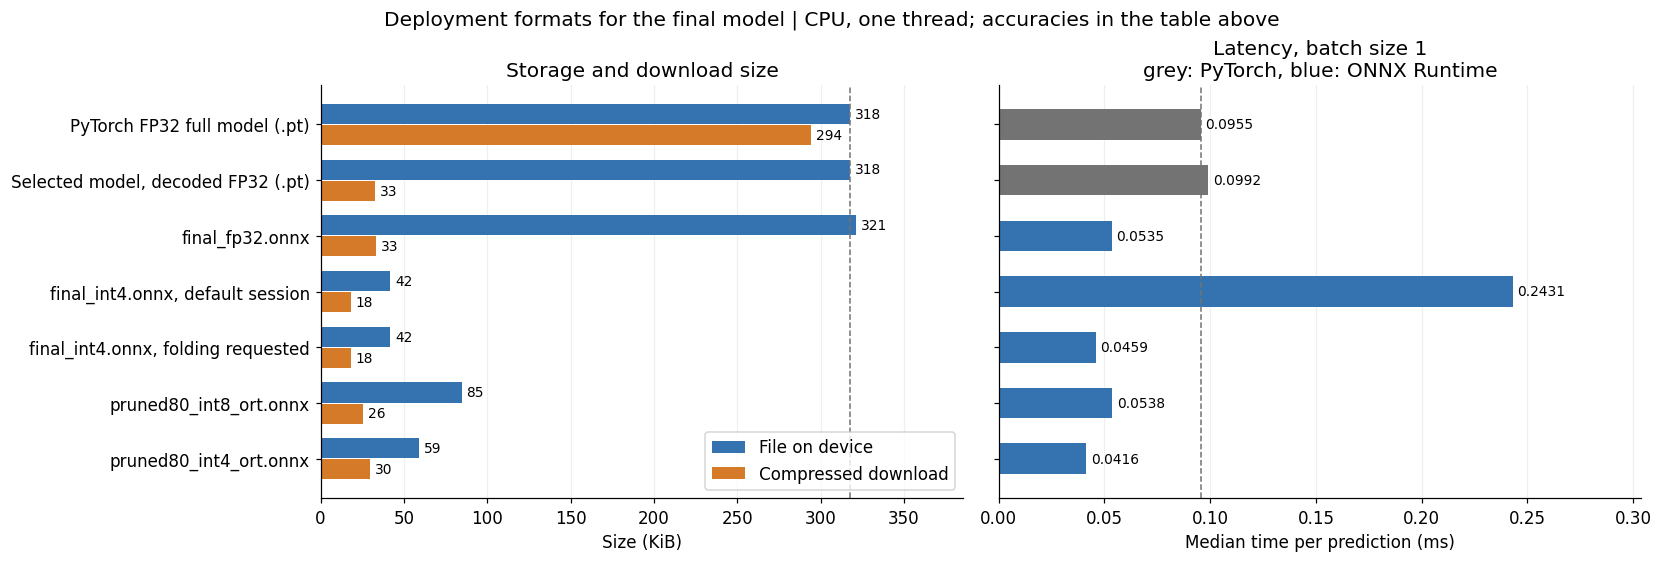

In [63]:
BLUE, ORANGE, GREY = "#3572B0", "#D47A28", "#737373"
names = [r["model"] for r in deployment_results]
positions = np.arange(len(names))
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, layout="constrained")

ax = axes[0]
file_kib = [r["file_bytes"] / 1024 for r in deployment_results]
zip_kib = [r["compressed_bytes"] / 1024 for r in deployment_results]
bars_file = ax.barh(positions - 0.19, file_kib, height=0.36, color=BLUE, label="File on device")
bars_zip = ax.barh(positions + 0.19, zip_kib, height=0.36, color=ORANGE, label="Compressed download")
ax.bar_label(bars_file, labels=[f"{v:.0f}" for v in file_kib], padding=3, fontsize=9)
ax.bar_label(bars_zip, labels=[f"{v:.0f}" for v in zip_kib], padding=3, fontsize=9)
ax.axvline(file_kib[0], color=GREY, linestyle="--", linewidth=1)
ax.set_xlim(0, max(file_kib) * 1.2)
ax.set(xlabel="Size (KiB)", title="Storage and download size")
ax.legend(loc="lower right")

ax = axes[1]
latency = [r["latency_b1_ms"] for r in deployment_results]
bars = ax.barh(positions, latency, height=0.55, color=[GREY if "PyTorch" in r["runtime"] else BLUE
                                                       for r in deployment_results])
ax.bar_label(bars, labels=[f"{v:.4f}" for v in latency], padding=3, fontsize=9)
ax.axvline(latency[0], color=GREY, linestyle="--", linewidth=1)
ax.set_xlim(0, max(latency) * 1.25)
ax.set(xlabel="Median time per prediction (ms)", title="Latency, batch size 1\ngrey: PyTorch, blue: ONNX Runtime")

for ax in axes:
    ax.set_yticks(positions, names)
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)
axes[0].invert_yaxis()
fig.suptitle("Deployment formats for the final model | CPU, one thread; accuracies in the table above")
fig.savefig(ONNX_DIR / "figure_deployment.png", dpi=150)
plt.show()

### 8.8 Predict activities with the exported model

The predictor accepts one vector of 561 features or a batch with shape `(n, 561)`. It checks the input shape and rejects non-finite values. Activity names come from the dataset rather than a second manually maintained label list.

The example reuses `create_onnx_session()`. A standalone deployment needs that helper, this class, NumPy, ONNX Runtime, the saved model, and the activity label list. Softmax scores are model probabilities, not calibrated guarantees. Sensor feature extraction is still a separate step.

In [64]:
class ActivityClassifier:
    """Predict activity labels from the same feature representation used for training."""
    def __init__(self, model_path, labels, decode_at_load=True):
        self.session = create_onnx_session(model_path, decode_at_load=decode_at_load)
        self.input_name = self.session.get_inputs()[0].name
        self.feature_count = self.session.get_inputs()[0].shape[1]
        self.labels = list(labels)
        if self.session.get_outputs()[0].shape[1] != len(self.labels):
            raise ValueError("Label count does not match the model output.")

    def predict(self, features):
        batch = np.asarray(features, dtype=np.float32)
        if batch.ndim == 1:
            batch = batch[None, :]
        if batch.ndim != 2 or batch.shape[1] != self.feature_count or len(batch) == 0:
            raise ValueError(f"Expected a nonempty array with shape (n, {self.feature_count}).")
        if not np.isfinite(batch).all():
            raise ValueError("Features contain NaN or infinity.")
        logits = self.session.run(None, {self.input_name: batch})[0]
        probabilities = np.exp(logits - logits.max(axis=1, keepdims=True))
        probabilities /= probabilities.sum(axis=1, keepdims=True)
        return [(self.labels[k], float(row[k]))
                for k, row in zip(probabilities.argmax(1), probabilities)]

device_model = ActivityClassifier(final_int4_path, ACTIVITIES)
sample_rows = np.linspace(0, len(prune_y_val) - 1, min(5, len(prune_y_val)), dtype=int)
for row, (activity, probability) in zip(sample_rows, device_model.predict(prune_X_val.numpy()[sample_rows])):
    print(f"Window {row:4d}: predicted {activity} ({probability:.1%}) | true {ACTIVITIES[int(prune_y_val[row])]}")

(ONNX_DIR / "activity_labels.json").write_text(json.dumps(ACTIVITIES, indent=2), encoding="utf-8")

Window    0: predicted Standing (100.0%) | true Standing
Window  450: predicted Walking (86.3%) | true Walking
Window  900: predicted Sitting (98.7%) | true Sitting
Window 1350: predicted Walking (97.1%) | true Walking
Window 1800: predicted Walking Upstairs (100.0%) | true Walking Upstairs


104

### 8.9 Interpret your results

Use the generated table and plot from **this run**:

- **Conversion fidelity:** the direct export and the custom UINT4 graph must reproduce the selected PyTorch model's predictions. The library quantizers are alternatives and need their own accuracy evaluation.
- **Storage:** actual file sizes include metadata. UINT4 stores zeros too, so it does not realize section 7's sparse-payload estimate. Compressed bytes describe transfer/storage compression, not runtime RAM.
- **Runtime:** compare the two ONNX session modes and the PyTorch references. A speed difference across frameworks is not evidence that pruning alone accelerated dense matrix operations.
- **Selection:** use validation accuracy, the chosen tolerance, and deployment constraints together. File size and latency alone are insufficient.
- **Limits:** timings apply to this CPU and runtime version, exclude feature extraction and model loading, and do not measure RAM or energy. Benchmark on the intended device before deployment.

The table and metrics are saved to `onnx_artifacts/comparison.md` and `onnx_artifacts/results.json`. Keep the chosen models frozen for the final test evaluation.

### Discuss with students

1. Why check both logits and predicted labels after export?
2. Why can the selected low-bit model still produce a large FP32 ONNX file?
3. How do actual file size, estimated packed payload, compressed download size, and runtime memory differ?
4. Does your runtime remove dequantization nodes when folding is requested? What happens to measured latency?
5. Which model would you choose under a storage limit, and which measurements support that choice?

---

## 9. Final test evaluation and memory comparison

**Question:** after selecting models on validation participants, how well do they recognize activities for different people, and what resources do they require?

We use the **official test set**, whose participants are separate from training and validation. Keep every model and compression setting frozen. This section evaluates the models already created; it does not train, tune, or choose a new winner using test accuracy.

| Part | What we compare |
|---|---|
| 9.1 | Prepare the test data and reusable reporting helpers |
| 9.2 | Original FP32 baseline and its activity-level errors |
| 9.3 | Quantized models from the quantization experiment |
| 9.4 | Global pruning before and after fine-tuning |
| 9.5 | The four models in section 7's `combined_models` |
| 9.6 | Deployment files and sessions from section 8 |
| 9.7 | Model tensor memory and a final deployment summary |

**Read the metrics:** accuracy is the fraction of correct windows; macro F1 gives each activity equal weight. Changes in accuracy are in **percentage points (pp)** relative to the FP32 **test** result. Validation and test involve different participants, so their scores can differ.

**Memory is not file size.** We report the numerical payload of model tensors in KiB (1 KiB = 1,024 bytes). This excludes activations, allocator and runtime overhead, and is not a measurement of peak process RAM. Actual deployment-file sizes and warmed latency come from section 8.

### 9.1 Prepare the final evaluation

Run sections 1–8 in order first. Results are cached per PyTorch model so repeated appearances in comparison tables reuse the same test predictions.

In [65]:
for required in ("X_test", "y_test", "subject_test", "quantization_models", "pruned_models",
                 "finetuned_models", "combo_lowbit_model", "final_fp32_session", "combined_models", "combined_results",
                 "deployment_results", "evaluate_onnx", "final_int4_session",
                 "final_int4_loaded_session", "ort_int8_session", "ort_int4_session"):
    assert required in globals(), f"Run sections 1-8 first: '{required}' is missing"

TEST_DIR = Path("final_test_artifacts")
TEST_DIR.mkdir(exist_ok=True)
test_X = torch.from_numpy(X_test)
test_y = torch.from_numpy(y_test)
assert set(np.unique(subject_test)).isdisjoint(np.unique(subject_train))
print(f"Official test set: {len(test_y):,} windows from {len(np.unique(subject_test))} unseen participants")

def torch_logits(model, X, input_dtype=torch.float32, batch_size=64):
    model.eval()
    with torch.inference_mode():
        return torch.cat([model(X[i:i + batch_size].to(input_dtype)).float()
                          for i in range(0, len(X), batch_size)])

def onnx_logits(session, X, batch_size=64):
    name = session.get_inputs()[0].name
    data = X.numpy()
    return torch.from_numpy(np.concatenate([session.run(None, {name: data[i:i + batch_size]})[0]
                                            for i in range(0, len(data), batch_size)]))

def test_metrics(logits):
    predictions = logits.argmax(1)
    return {"test_accuracy": (predictions == test_y).double().mean().item(),
            "test_macro_f1": f1_score(test_y.numpy(), predictions.numpy(), average="macro"),
            "test_loss": nn.functional.cross_entropy(logits, test_y).item(),
            "predictions": predictions}

def table(rows, columns):
    """Markdown table from a list of dicts; columns = [(header, key, format, align)]."""
    head = "| " + " | ".join(h for h, _, _, _ in columns) + " |"
    rule = "|" + "|".join("---:" if a == "r" else "---" for _, _, _, a in columns) + "|"
    body = ["| " + " | ".join(f.format(r[k]) if r.get(k) is not None else "–" for _, k, f, _ in columns) + " |"
            for r in rows]
    return "\n".join([head, rule] + body)

def dumbbell(rows, title, path, reference=None):
    """One row per model: hollow = validation accuracy, filled = test accuracy."""
    names = [r["model"] for r in rows]
    val = [100 * r["val_accuracy"] for r in rows]
    test = [100 * r["test_accuracy"] for r in rows]
    y = np.arange(len(rows))
    fig, ax = plt.subplots(figsize=(10, 0.55 * len(rows) + 1.8), layout="constrained")
    for yi, v, t in zip(y, val, test):
        ax.plot([v, t], [yi, yi], color="#B8C4D0", linewidth=2, zorder=1)
    ax.scatter(val, y, s=70, facecolor="white", edgecolor=BLUE, linewidth=2, zorder=2, label="Validation")
    ax.scatter(test, y, s=70, color=BLUE, zorder=3, label="Test")
    for yi, t in zip(y, test):
        ax.annotate(f"{t:.2f}%", (t, yi), textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=9, color="#242424")
    if reference is not None:
        ax.axvline(100 * reference, color=GREY, linestyle="--", linewidth=1.2, label="FP32 test accuracy")
    low = min(val + test)
    ax.set_xlim(max(0, low - 3), 100)
    ax.set_yticks(y, names)
    ax.set_ylim(len(rows) - 0.4, -0.7)
    ax.set_xlabel("Accuracy (%)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.2)
    ax.legend(loc="lower right", fontsize=9)
    fig.savefig(path, dpi=150)
    plt.show()

all_test_results = {}

def model_tensor_bytes(model):
    """Numerical tensor payload, including packed INT8 weights exposed by state_dict.

    This is a representation-size estimate, not allocator usage or peak runtime RAM.
    """
    seen = set()
    def visit(value):
        if isinstance(value, torch.Tensor):
            key = (value.untyped_storage().data_ptr(), value.untyped_storage().nbytes())
            if key in seen:
                return 0
            seen.add(key)
            size = value.numel() * value.element_size()
            if value.is_quantized:
                if value.qscheme() in (torch.per_channel_affine, torch.per_channel_symmetric):
                    size += visit(value.q_per_channel_scales()) + visit(value.q_per_channel_zero_points())
                else:
                    size += 16  # scalar scale and zero point, counted as 8 bytes each
            return size
        if isinstance(value, dict):
            return sum(visit(v) for v in value.values())
        if isinstance(value, (tuple, list)):
            return sum(visit(v) for v in value)
        return 0
    return int(visit(model.state_dict()))

torch_test_cache = {}
def evaluate_test_model(model, input_dtype=torch.float32):
    key = (id(model), input_dtype)
    if key not in torch_test_cache:
        torch_test_cache[key] = test_metrics(torch_logits(model, test_X, input_dtype))
    return torch_test_cache[key]

metric_columns = [
    ("Model", "model", "{}", "l"),
    ("Validation acc.", "val_accuracy", "{:.2%}", "r"),
    ("Test acc.", "test_accuracy", "{:.2%}", "r"),
    ("Change vs FP32 test (pp)", "change_pp", "{:+.2f}", "r"),
    ("Test macro F1", "test_macro_f1", "{:.4f}", "r")
]


Official test set: 2,947 windows from 9 unseen participants


### 9.2 The FP32 original model

First the reference: how well does the uncompressed model work for new people? Besides accuracy, we look at each activity separately and at the confusion matrix (rows = true activity, columns = predicted activity).

| Model | Validation acc. | Test acc. | Test macro F1 | Test loss | Validation − test (pp) |
|---|---:|---:|---:|---:|---:|
| FP32 original | 96.67% | 94.98% | 0.9493 | 0.1527 | +1.69 |

                    precision    recall  f1-score   support

           Walking      0.962     0.974     0.968       496
  Walking Upstairs      0.946     0.964     0.955       471
Walking Downstairs      0.968     0.931     0.949       420
           Sitting      0.955     0.862     0.906       491
          Standing      0.880     0.962     0.919       532
        Lying down      1.000     0.998     0.999       537

          accuracy                          0.950      2947
         macro avg      0.952     0.948     0.949      2947
      weighted avg      0.951     0.950     0.950      2947



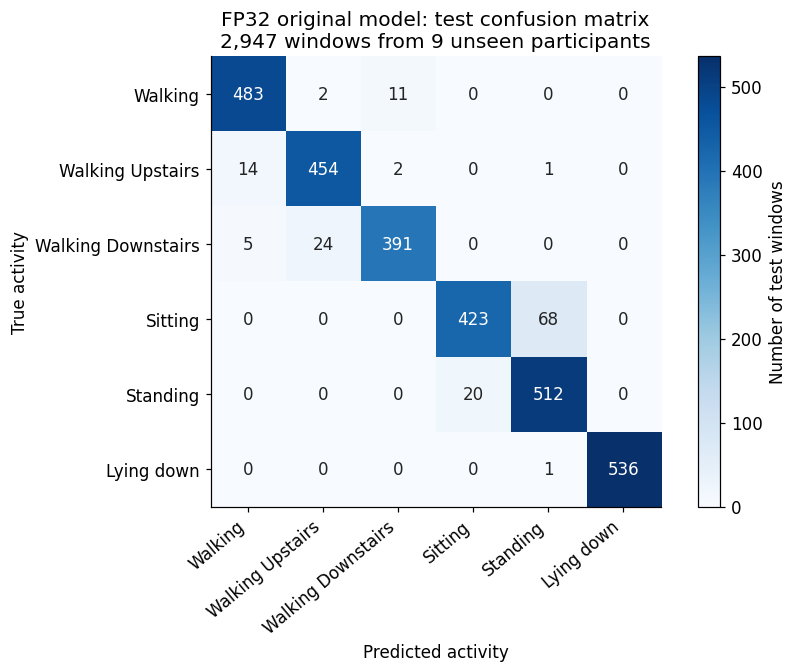

In [66]:
fp32_test = evaluate_test_model(prune_reference)
fp32_test_accuracy = fp32_test["test_accuracy"]
fp32_row = {"model": "FP32 original", "val_accuracy": fp32_accuracy, **fp32_test,
            "change_pp": 0.0, "generalization_gap_pp": 100 * (fp32_accuracy - fp32_test_accuracy)}
all_test_results["fp32"] = [fp32_row]

display(Markdown(table([fp32_row], [
    ("Model", "model", "{}", "l"), ("Validation acc.", "val_accuracy", "{:.2%}", "r"),
    ("Test acc.", "test_accuracy", "{:.2%}", "r"), ("Test macro F1", "test_macro_f1", "{:.4f}", "r"),
    ("Test loss", "test_loss", "{:.4f}", "r"),
    ("Validation − test (pp)", "generalization_gap_pp", "{:+.2f}", "r")])))
print(classification_report(test_y.numpy(), fp32_test["predictions"].numpy(), labels=np.arange(6),
                            target_names=ACTIVITIES, digits=3, zero_division=0))

cm = confusion_matrix(test_y.numpy(), fp32_test["predictions"].numpy(), labels=np.arange(6))
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
image = ax.imshow(cm, cmap="Blues", vmin=0)
fig.colorbar(image, ax=ax, label="Number of test windows")
ax.set_xticks(np.arange(6), ACTIVITIES, rotation=40, ha="right")
ax.set_yticks(np.arange(6), ACTIVITIES)
for r in range(6):
    for c in range(6):
        ax.text(c, r, str(cm[r, c]), ha="center", va="center",
                color="white" if cm[r, c] > cm.max() / 2 else "#242424")
ax.set(xlabel="Predicted activity", ylabel="True activity",
       title=f"FP32 original model: test confusion matrix\n{len(test_y):,} windows from {len(np.unique(subject_test))} unseen participants")
fig.savefig(TEST_DIR / "figure_fp32_confusion.png", dpi=150)
plt.show()

**How to read the results:** diagonal confusion-matrix entries are correct predictions; off-diagonal entries show which activities are confused. Check the per-class report before concluding that a high overall accuracy means all activities are equally easy.

The validation–test difference describes this participant split. It is not, by itself, proof of overfitting. Use the FP32 **test accuracy** as the reference for every test comparison below.

### 9.3 Quantization: accuracy and model tensor memory

Reuse `quantization_models` and `quantization_results`. FP16 receives FP16 inputs. The INT1–INT4 models use reconstructed FP32 weights in PyTorch, so their tensor memory does not shrink just because their names describe fewer bits. Dynamic INT8 stores quantized weights; its packed representation is included in the tensor estimate.

| Model | Validation acc. | Test acc. | Change vs FP32 test (pp) | Test macro F1 | Model tensor KiB |
|---|---:|---:|---:|---:|---:|
| FP32 | 96.67% | 94.98% | +0.00 | 0.9493 | 314.8 |
| FP16 | 96.67% | 94.98% | +0.00 | 0.9493 | 157.4 |
| INT8 | 96.78% | 94.77% | -0.20 | 0.9471 | 79.4 |
| INT4 | 96.39% | 95.08% | +0.10 | 0.9500 | 314.8 |
| INT3 | 92.39% | 89.21% | -5.77 | 0.8886 | 314.8 |
| INT2 | 75.90% | 75.81% | -19.17 | 0.7588 | 314.8 |
| INT1 | 80.12% | 79.47% | -15.51 | 0.7774 | 314.8 |

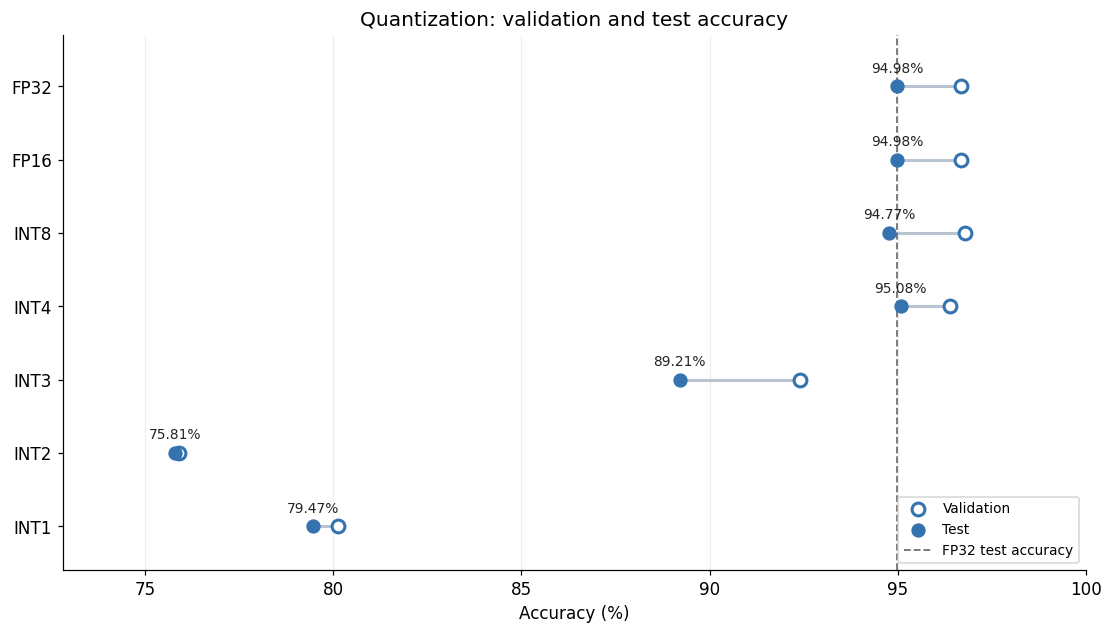

In [67]:
quant_test_rows = []
for row in quantization_results:
    label = row["version"]
    model = quantization_models[label]
    dtype = torch.float16 if label == "FP16" else torch.float32
    metrics = evaluate_test_model(model, dtype)
    quant_test_rows.append({
        "model": label, "val_accuracy": row["accuracy"], **metrics,
        "change_pp": 100 * (metrics["test_accuracy"] - fp32_test_accuracy),
        "tensor_kib": model_tensor_bytes(model) / 1024
    })
all_test_results["quantization"] = quant_test_rows
display(Markdown(table(quant_test_rows, metric_columns + [
    ("Model tensor KiB", "tensor_kib", "{:.1f}", "r")
])))
dumbbell(quant_test_rows, "Quantization: validation and test accuracy",
         TEST_DIR / "figure_quantization_test.png", reference=fp32_test_accuracy)

**What to look for:** which precision levels stay close to FP32 on the test participants? Compare accuracy changes with tensor memory rather than assuming every lower-bit experiment reduces RAM. Small accuracy differences on one test split do not establish that one method is reliably better.

### 9.4 Pruning: before and after fine-tuning

The current pruning experiment creates `pruned_models[sparsity]` using global magnitude pruning, then stores its fine-tuned counterpart in `finetuned_models[sparsity]`. Compare these two families at each requested sparsity.

Zeroing weights leaves the dense tensor dimensions unchanged. The memory column therefore remains approximately constant even at high sparsity. A sparse storage estimate is a different quantity and was explored earlier.

| Sparsity | Before: test acc. | After: test acc. | After: validation acc. | After: test macro F1 | Selected epoch | Model tensor KiB |
|---:|---:|---:|---:|---:|---:|---:|
| 10% | 94.88% | 94.88% | 96.78% | 0.9483 | 0 | 314.8 |
| 20% | 94.84% | 94.84% | 96.61% | 0.9478 | 0 | 314.8 |
| 30% | 94.84% | 94.84% | 96.56% | 0.9478 | 0 | 314.8 |
| 40% | 94.98% | 94.98% | 96.61% | 0.9492 | 0 | 314.8 |
| 50% | 94.77% | 94.77% | 97.00% | 0.9472 | 0 | 314.8 |
| 60% | 93.89% | 93.89% | 96.67% | 0.9385 | 0 | 314.8 |
| 70% | 92.37% | 92.37% | 95.84% | 0.9236 | 0 | 314.8 |
| 80% | 83.51% | 93.65% | 96.00% | 0.9365 | 9 | 314.8 |
| 90% | 67.97% | 92.94% | 95.39% | 0.9286 | 10 | 314.8 |
| 95% | 63.49% | 89.89% | 93.23% | 0.8979 | 10 | 314.8 |

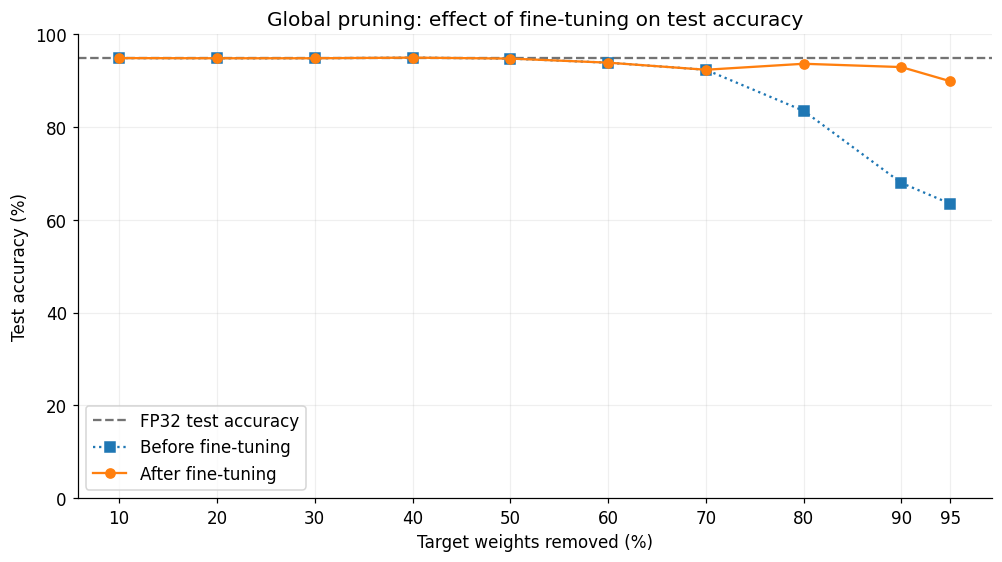

In [68]:
prune_test_rows = []
for row in finetune_results:
    sparsity = row["sparsity"]
    before = evaluate_test_model(pruned_models[sparsity])
    after = evaluate_test_model(finetuned_models[sparsity])
    prune_test_rows.append({
        "sparsity": sparsity, "before_test": before["test_accuracy"],
        "after_test": after["test_accuracy"], "val_accuracy": row["after_accuracy"],
        "test_macro_f1": after["test_macro_f1"], "best_epoch": row["best_epoch"],
        "change_pp": 100 * (after["test_accuracy"] - fp32_test_accuracy),
        "tensor_kib": model_tensor_bytes(finetuned_models[sparsity]) / 1024
    })
all_test_results["pruning"] = prune_test_rows
display(Markdown(table(prune_test_rows, [
    ("Sparsity", "sparsity", "{:.0%}", "r"),
    ("Before: test acc.", "before_test", "{:.2%}", "r"),
    ("After: test acc.", "after_test", "{:.2%}", "r"),
    ("After: validation acc.", "val_accuracy", "{:.2%}", "r"),
    ("After: test macro F1", "test_macro_f1", "{:.4f}", "r"),
    ("Selected epoch", "best_epoch", "{}", "r"),
    ("Model tensor KiB", "tensor_kib", "{:.1f}", "r")
])))
xs = [100 * row["sparsity"] for row in prune_test_rows]
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
ax.axhline(100 * fp32_test_accuracy, color=GREY, linestyle="--", label="FP32 test accuracy")
ax.plot(xs, [100 * row["before_test"] for row in prune_test_rows], "s:", label="Before fine-tuning")
ax.plot(xs, [100 * row["after_test"] for row in prune_test_rows], "o-", label="After fine-tuning")
ax.set(xticks=xs, ylim=(0, 100), xlabel="Target weights removed (%)",
       ylabel="Test accuracy (%)", title="Global pruning: effect of fine-tuning on test accuracy")
ax.grid(alpha=0.2)
ax.legend()
fig.savefig(TEST_DIR / "figure_pruning_test.png", dpi=150)
plt.show()

**Interpretation:** a selected epoch of 0 means validation loss kept the original pruned model, so before/after predictions should match. At higher sparsity, inspect whether fine-tuning recovered useful accuracy. Keep the epoch and sparsity choices fixed even if the test ranking differs from validation.

### 9.5 Combine pruning and quantization

Use exactly the four entries from section 7's `combined_models`: FP32, quantization alone, pruning plus fine-tuning, and their selected combination. Match each model to `combined_results` by its name.

The table deliberately separates **estimated packed payload** from **model tensor memory**. The former assumes a storage scheme; the latter reflects the tensors used by these PyTorch models.

| Model | Validation acc. | Test acc. | Change vs FP32 test (pp) | Test macro F1 | Estimated packed KiB | Model tensor KiB |
|---|---:|---:|---:|---:|---:|---:|
| FP32 | 96.67% | 94.98% | +0.00 | 0.9493 | 314.8 | 314.8 |
| INT4 only | 96.39% | 95.08% | +0.10 | 0.9500 | 41.6 | 314.8 |
| Pruned 80% + fine-tuned | 96.00% | 93.65% | -1.32 | 0.9365 | 73.4 | 314.8 |
| Pruned + INT4 | 95.95% | 93.89% | -1.09 | 0.9389 | 20.0 | 314.8 |

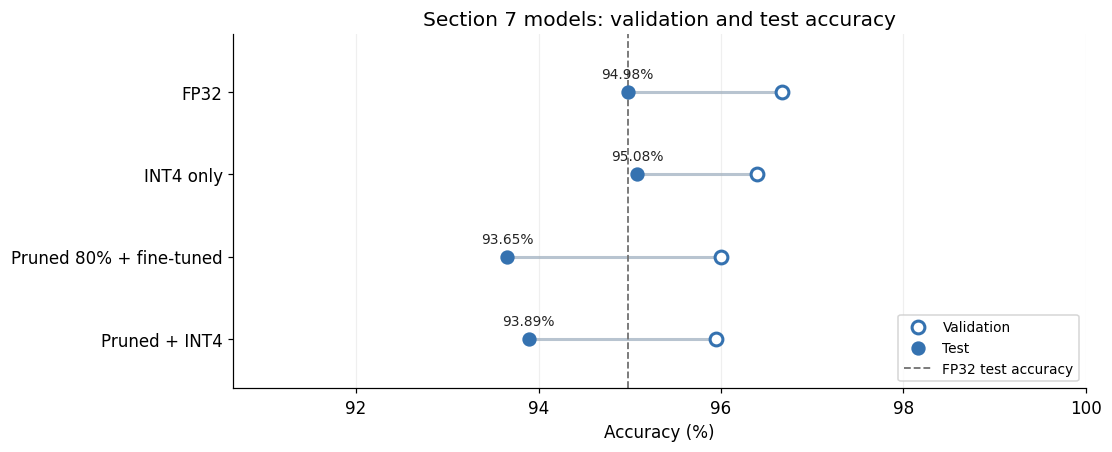

In [69]:
combined_validation = {row["model"]: row for row in combined_results}
mixed_test_rows = []
for name, model in combined_models.items():
    previous = combined_validation[name]
    metrics = evaluate_test_model(model)
    mixed_test_rows.append({
        "model": name, "val_accuracy": previous["accuracy"], **metrics,
        "change_pp": 100 * (metrics["test_accuracy"] - fp32_test_accuracy),
        "estimated_payload_kib": previous["estimated_payload_bytes"] / 1024,
        "tensor_kib": model_tensor_bytes(model) / 1024
    })
all_test_results["combined"] = mixed_test_rows
display(Markdown(table(mixed_test_rows, metric_columns + [
    ("Estimated packed KiB", "estimated_payload_kib", "{:.1f}", "r"),
    ("Model tensor KiB", "tensor_kib", "{:.1f}", "r")
])))
dumbbell(mixed_test_rows, "Section 7 models: validation and test accuracy",
         TEST_DIR / "figure_combined_test.png", reference=fp32_test_accuracy)

**Question:** did combining the two techniques retain the accuracy seen on validation? Read the actual test change in the table. The tolerance was a validation selection rule, not a guaranteed test bound. A compact hypothetical payload does not mean the running model occupies that amount of RAM.

### 9.6 Verify the deployment files on test data

Reuse section 8's `evaluate_onnx(session, X, y)` and all five deployment sessions. The direct FP32 export and both UINT4 session modes must preserve the selected PyTorch model's predictions. ONNX Runtime's INT8 and INT4 quantizers produce alternative models, so their predictions can differ.

File size measures storage. We do not infer ONNX runtime RAM from initializer size: graph optimizations, decoded weights, and runtime buffers change memory usage.

Passed: all three exact-conversion sessions preserve the selected model's test predictions.


| Model | Validation acc. | Test acc. | Change vs FP32 test (pp) | Test macro F1 | Actual file KiB |
|---|---:|---:|---:|---:|---:|
| final_fp32.onnx | 95.95% | 93.89% | -1.09 | 0.9389 | 321.5 |
| final_int4.onnx, default session | 95.95% | 93.89% | -1.09 | 0.9389 | 41.9 |
| final_int4.onnx, folding requested | 95.95% | 93.89% | -1.09 | 0.9389 | 41.9 |
| pruned80_int8_ort.onnx | 96.06% | 93.76% | -1.22 | 0.9375 | 84.6 |
| pruned80_int4_ort.onnx | 95.78% | 93.79% | -1.19 | 0.9378 | 59.4 |

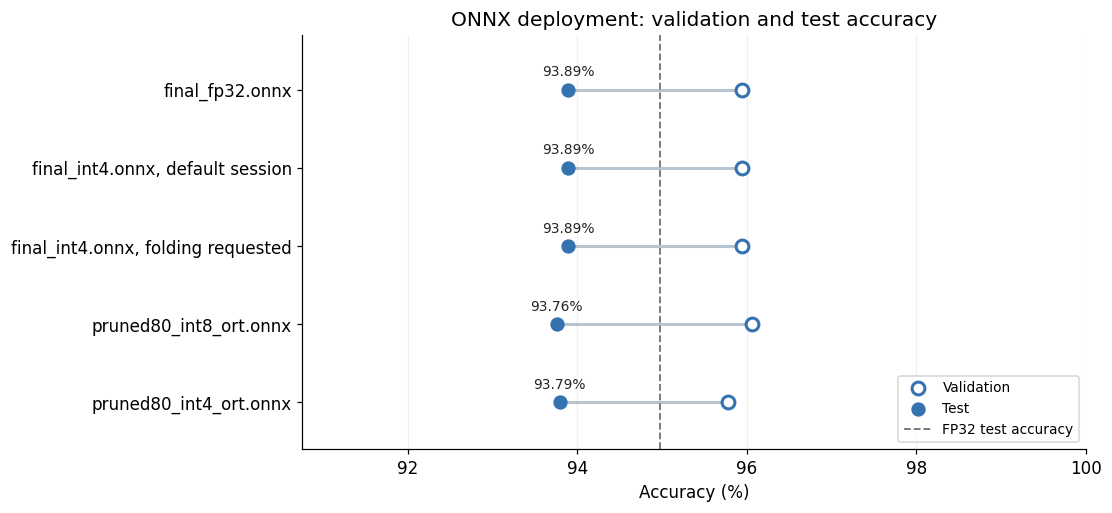

In [70]:
onnx_models = [
    (final_fp32_path.name, final_fp32_session, final_fp32_metrics, final_fp32_path),
    ("final_int4.onnx, default session", final_int4_session, final_int4_metrics, final_int4_path),
    ("final_int4.onnx, folding requested", final_int4_loaded_session, final_int4_loaded_metrics, final_int4_path),
    (ort_int8_path.name, ort_int8_session, ort_int8_metrics, ort_int8_path),
    (ort_int4_path.name, ort_int4_session, ort_int4_metrics, ort_int4_path)
]
final_torch_test = evaluate_test_model(combo_lowbit_model)
onnx_test_rows = []
for name, session, validation, path in onnx_models:
    metrics = evaluate_onnx(session, test_X, test_y)
    predictions = torch.from_numpy(metrics["logits"].argmax(axis=1))
    onnx_test_rows.append({
        "model": name, "val_accuracy": validation["accuracy"],
        "test_accuracy": metrics["accuracy"], "test_macro_f1": metrics["macro_f1"],
        "test_loss": metrics["loss"], "predictions": predictions,
        "change_pp": 100 * (metrics["accuracy"] - fp32_test_accuracy),
        "file_kib": path.stat().st_size / 1024
    })
for row in onnx_test_rows[:3]:
    assert torch.equal(row["predictions"], final_torch_test["predictions"]), row["model"]
print("Passed: all three exact-conversion sessions preserve the selected model's test predictions.")
all_test_results["onnx"] = onnx_test_rows
display(Markdown(table(onnx_test_rows, metric_columns + [
    ("Actual file KiB", "file_kib", "{:.1f}", "r")
])))
dumbbell(onnx_test_rows, "ONNX deployment: validation and test accuracy",
         TEST_DIR / "figure_onnx_test.png", reference=fp32_test_accuracy)

**What to notice:** equal predictions confirm conversion fidelity on this dataset. Compare the library-quantized models separately. Neither a smaller ONNX file nor a faster measured prediction establishes lower total RAM; that needs profiling on the intended runtime and device.

### 9.7 Show memory and summarize the deployment options

**Model tensor memory:** count each unique tensor's numerical payload from the PyTorch state dictionary, including the dynamic INT8 packed weight/bias tuple and quantization metadata. This is an estimate of representation size. It excludes Python objects, backend packing overhead, activation buffers, gradients, allocator reservations, and loaded libraries; it is **not peak RAM**.

FP16 should roughly halve the FP32 tensor payload. Dense pruned models and the reconstructed INT1–INT4 models still use FP32 tensors. This explains why compression can reduce storage without reducing the tensors used during inference.

The final table then combines test accuracy with **actual file size and latency from section 8**. ONNX runtime memory is marked unmeasured rather than substituted with file size.

| Model | Model tensor KiB | Relative to FP32 |
|---|---:|---:|
| FP32 | 314.8 | 100.0% |
| FP16 | 157.4 | 50.0% |
| INT8 | 79.4 | 25.2% |
| INT4 | 314.8 | 100.0% |
| INT3 | 314.8 | 100.0% |
| INT2 | 314.8 | 100.0% |
| INT1 | 314.8 | 100.0% |
| Pruned 80% + fine-tuned | 314.8 | 100.0% |
| Final: pruned 80% + INT4 | 314.8 | 100.0% |

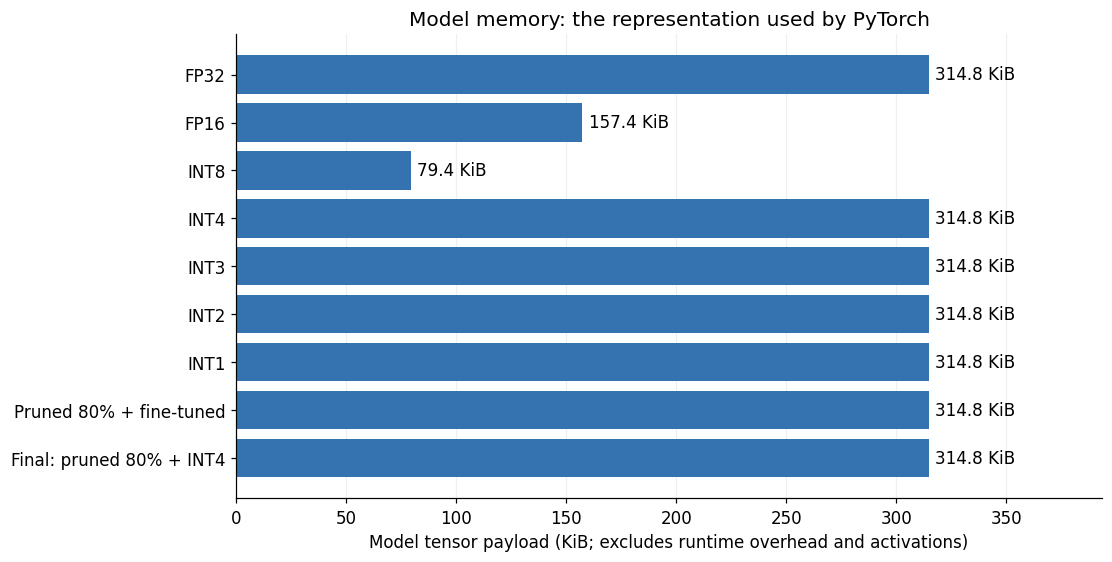

#### Final deployment summary

A dash means memory was not measured for that runtime.

| Model | Actual file KiB | Model tensor KiB | Test acc. | Change vs FP32 (pp) | Test macro F1 | Section 8 latency (ms) |
|---|---:|---:|---:|---:|---:|---:|
| PyTorch FP32 full model (.pt) | 317.8 | 314.8 | 94.98% | +0.00 | 0.9493 | 0.0955 |
| Selected model, decoded FP32 (.pt) | 318.0 | 314.8 | 93.89% | -1.09 | 0.9389 | 0.0992 |
| final_fp32.onnx | 321.5 | – | 93.89% | -1.09 | 0.9389 | 0.0535 |
| final_int4.onnx, default session | 41.9 | – | 93.89% | -1.09 | 0.9389 | 0.2431 |
| final_int4.onnx, folding requested | 41.9 | – | 93.89% | -1.09 | 0.9389 | 0.0459 |
| pruned80_int8_ort.onnx | 84.6 | – | 93.76% | -1.22 | 0.9375 | 0.0538 |
| pruned80_int4_ort.onnx | 59.4 | – | 93.79% | -1.19 | 0.9378 | 0.0416 |

Selected in section 7: 80% pruning + INT4.
FP32 test accuracy: 94.98%; selected model: 93.89%.


In [71]:
memory_rows = []
for name, model in list(quantization_models.items()) + [
    (f"Pruned {BEST_SPARSITY:.0%} + fine-tuned", best_pruned_model),
    (f"Final: pruned {BEST_SPARSITY:.0%} + INT{BEST_BITS}", combo_lowbit_model)
]:
    memory_rows.append({"model": name, "tensor_kib": model_tensor_bytes(model) / 1024})
reference_memory = model_tensor_bytes(prune_reference)
for row in memory_rows:
    row["relative_percent"] = 100 * row["tensor_kib"] * 1024 / reference_memory
assert reference_memory == sum(t.numel() * t.element_size() for t in prune_reference.state_dict().values())
assert model_tensor_bytes(quantization_models["FP16"]) * 2 == model_tensor_bytes(quantization_models["FP32"])
assert model_tensor_bytes(quantization_models["INT8"]) < reference_memory
assert model_tensor_bytes(combo_lowbit_model) == reference_memory
all_test_results["memory"] = memory_rows
display(Markdown(table(memory_rows, [
    ("Model", "model", "{}", "l"), ("Model tensor KiB", "tensor_kib", "{:.1f}", "r"),
    ("Relative to FP32", "relative_percent", "{:.1f}%", "r")
])))
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
values = [row["tensor_kib"] for row in memory_rows]
bars = ax.barh([row["model"] for row in memory_rows], values, color=BLUE)
ax.bar_label(bars, fmt="%.1f KiB", padding=4)
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.25)
ax.set(xlabel="Model tensor payload (KiB; excludes runtime overhead and activations)",
       title="Model memory: the representation used by PyTorch")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
fig.savefig(TEST_DIR / "figure_model_memory.png", dpi=150)
plt.show()

display(Markdown("#### Final deployment summary\n\nA dash means memory was not measured for that runtime."))
test_by_name = {row["model"]: row for row in onnx_test_rows}
test_by_name["PyTorch FP32 full model (.pt)"] = fp32_test
test_by_name["Selected model, decoded FP32 (.pt)"] = final_torch_test
summary_rows = []
for previous in deployment_results:
    name = previous["model"]
    result = test_by_name[name]
    tensor_kib = None
    if name == "PyTorch FP32 full model (.pt)":
        tensor_kib = reference_memory / 1024
    elif name == "Selected model, decoded FP32 (.pt)":
        tensor_kib = model_tensor_bytes(combo_lowbit_model) / 1024
    summary_rows.append({
        "model": name, "file_kib": previous["file_bytes"] / 1024,
        "tensor_kib": tensor_kib, "test_accuracy": result["test_accuracy"],
        "test_macro_f1": result["test_macro_f1"],
        "change_pp": 100 * (result["test_accuracy"] - fp32_test_accuracy),
        "latency_ms": previous["latency_b1_ms"]
    })
all_test_results["summary"] = summary_rows
display(Markdown(table(summary_rows, [
    ("Model", "model", "{}", "l"), ("Actual file KiB", "file_kib", "{:.1f}", "r"),
    ("Model tensor KiB", "tensor_kib", "{:.1f}", "r"),
    ("Test acc.", "test_accuracy", "{:.2%}", "r"),
    ("Change vs FP32 (pp)", "change_pp", "{:+.2f}", "r"),
    ("Test macro F1", "test_macro_f1", "{:.4f}", "r"),
    ("Section 8 latency (ms)", "latency_ms", "{:.4f}", "r")
])))
print(f"Selected in section 7: {BEST_SPARSITY:.0%} pruning + INT{BEST_BITS}.")
print(f"FP32 test accuracy: {fp32_test_accuracy:.2%}; selected model: {final_torch_test['test_accuracy']:.2%}.")

In [72]:
def serializable(rows):
    return [{k: (float(v) if isinstance(v, (np.floating, float)) else v)
             for k, v in r.items() if k != "predictions"} for r in rows]

(TEST_DIR / "results.json").write_text(json.dumps({
    "memory_definition": "Numerical model tensor payload; excludes activations and runtime overhead; not peak RAM.",
    "selected_bits": BEST_BITS, "selected_sparsity": BEST_SPARSITY,
    "test_windows": len(test_y), "test_participants": int(len(np.unique(subject_test))),
    "note": "Frozen models, evaluated once on the official test set; no decisions made from these results.",
    **{group: serializable(rows) for group, rows in all_test_results.items()}}, indent=2), encoding="utf-8")
for group, rows in all_test_results.items():
    rows = serializable(rows)
    with (TEST_DIR / f"{group}_test.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
print(f"Saved test results for {len(all_test_results)} groups to {TEST_DIR}")

Saved test results for 7 groups to final_test_artifacts


### What should students conclude?

Base your answers on the tables and plots from this run:

1. Which activities account for most baseline errors?
2. Which compression settings preserve test accuracy, and where does accuracy deteriorate?
3. How much does fine-tuning recover after pruning? Why must the selected epoch still come from validation?
4. Why do the INT4 simulation and dense pruned models retain FP32-sized tensor memory?
5. How do estimated packed storage, actual file size, tensor memory, and peak process RAM differ?
6. Which already-selected deployment option fits your device constraints? What additional RAM, energy, and device-latency measurements would you need?

**Keep the conclusion bounded:** these results describe one participant split and this computer's runtime. Do not retune against the test results. Repeat training with predefined seeds and evaluate on additional held-out participants for stronger evidence.

Metrics are exported to `final_test_artifacts/results.json` and per-group CSVs. The memory plot is saved as `figure_model_memory.png`.